### $$\underline{\text{DHF : Lab 1}}$$ 

##### $$\text{Arnaud Capitan, Achraf Ouboujemaa, Vasco Nappa}$$ 
___



### Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

___

### Data Loading

In [2]:
stock_ids = ["0","1","2"]
day_ids = ["0","1","2","3","4"]
extensions = ["updates","trades"]

trades = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)
updates = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)

def get_data_path(stock_id, day, extension):
    return f"Data/stock{stock_id}_day{day}_{extension}.csv.gz"

for stock_id in stock_ids :
    for day_id in day_ids :
        data_path_updates = get_data_path(stock_id, day_id, "updates")
        data_path_trades = get_data_path(stock_id, day_id, "trades")
        df_updates = pd.read_csv(data_path_updates)
        df_trades = pd.read_csv(data_path_trades)
        df_updates["ts"] = pd.to_datetime(df_updates["ts"])
        df_trades["ts"] = pd.to_datetime(df_trades["ts"])
        updates[stock_ids.index(stock_id), day_ids.index(day_id)] = df_updates
        trades[stock_ids.index(stock_id), day_ids.index(day_id)] = df_trades

### Test of data loading :

In [3]:
print(updates[0,0].head())

                          ts type  bp       bq  ap       aq
0 2026-01-26 09:00:00.340497    U NaN  19671.0 NaN  24789.0
1 2026-01-26 09:00:00.503532    U NaN  19671.0 NaN  24789.0
2 2026-01-26 09:00:00.503539    U NaN  19671.0 NaN  24789.0
3 2026-01-26 09:00:00.503565    U NaN  19671.0 NaN  24789.0
4 2026-01-26 09:00:00.503735    U NaN  19671.0 NaN  24789.0


In [4]:
print(trades[0,0].head())

   price  qty                         ts
0  55.00    2 2026-01-26 09:00:27.018202
1  55.00   10 2026-01-26 09:00:27.018202
2  55.00   10 2026-01-26 09:00:27.018202
3  54.97  446 2026-01-26 09:00:27.041728
4  54.97   24 2026-01-26 09:00:27.042153


___

### Lab 1 : Questions

___

### 1. Trades

#### Question 1.1 :

For each stock, we will compute :

Using trades datasets :

- Daily average
- Daily volatility
- Daily sharpe-ratio
- Daily maximum / minimum / open / close / volume of quoted prices
- Daily tick size
- Daily bar chart for volume of trades (with time window)
- Daily prices based on trade events for each stock (and moving average based on event window)
- Daily correlation matrices between stock net returns (time-based to have same number of values, more or less in the same time window)



### Data preprocessing : 

We make sure that the dataset is correctly ordered in time, has no negative value, and that each event time is contained between 9:00 AM and 5:31 PM (since closing time is at 5:30 + random time).

In [5]:
def verify_order_time(df):
    if df["ts"].is_monotonic_increasing:
        return(True) #The timestamps are in increasing order
    else :
        return(False)

def verify_prices_positive(df):
    if (df["price"] > 0).all() :
        return(True) #All prices are positive
    else :
        return(False)

def verify_time_interval(df):
    if (df["ts"].dt.time >= pd.to_datetime("09:00:00").time()).all() and (df["ts"].dt.time <= pd.to_datetime("17:31:00").time()).all() :
        return(True) #All timestamps are between 9:00:00 and 17:00:00
    else :
        return(False)

def verify_quantities_positive(df):
    if (df["qty"] > 0).all() :
        return(True) #All quantities true
    else :
        return(False)

In [6]:
show_verification = True
if show_verification :
    for stock_id in stock_ids :
        for day_id in day_ids :
            df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
            print(f"\nStock {stock_id}, day {day_id} \t Trades timestamps in increasing order : {verify_order_time(df_trades)}")
            print(f"Stock {stock_id}, day {day_id} \t Traded prices are positive : {verify_prices_positive(df_trades)}")
            print(f"Stock {stock_id}, day {day_id} \t Trades timestamps are in interval [09:00:00, 17:31:00] : {verify_time_interval(df_trades)}")
            print(f"Stock {stock_id}, day {day_id} \t Traded quantities are positive : {verify_quantities_positive(df_trades)}")
        


Stock 0, day 0 	 Trades timestamps in increasing order : True
Stock 0, day 0 	 Traded prices are positive : True
Stock 0, day 0 	 Trades timestamps are in interval [09:00:00, 17:31:00] : True
Stock 0, day 0 	 Traded quantities are positive : True

Stock 0, day 1 	 Trades timestamps in increasing order : True
Stock 0, day 1 	 Traded prices are positive : True
Stock 0, day 1 	 Trades timestamps are in interval [09:00:00, 17:31:00] : True
Stock 0, day 1 	 Traded quantities are positive : True

Stock 0, day 2 	 Trades timestamps in increasing order : True
Stock 0, day 2 	 Traded prices are positive : True
Stock 0, day 2 	 Trades timestamps are in interval [09:00:00, 17:31:00] : True
Stock 0, day 2 	 Traded quantities are positive : True

Stock 0, day 3 	 Trades timestamps in increasing order : True
Stock 0, day 3 	 Traded prices are positive : True
Stock 0, day 3 	 Trades timestamps are in interval [09:00:00, 17:31:00] : True
Stock 0, day 3 	 Traded quantities are positive : True

Stock 0

The verification of the data above returns True for each stock every day. This was an expected results from stock trade prices. 

### Daily average and volatility :

In [7]:
for stock_id in stock_ids :
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        mean = df_trades["price"].copy().mean()
        volatility = df_trades["price"].copy().std()
        print(f"Stock {stock_id} Day {day_id} \t Mean : {mean:4f} \t Volatility : {volatility:4f}")



Stock 0 Day 0 	 Mean : 55.430137 	 Volatility : 0.165443
Stock 0 Day 1 	 Mean : 55.476423 	 Volatility : 0.161049
Stock 0 Day 2 	 Mean : 56.216857 	 Volatility : 0.189988
Stock 0 Day 3 	 Mean : 56.436704 	 Volatility : 0.401453
Stock 0 Day 4 	 Mean : 55.074316 	 Volatility : 0.276714


Stock 1 Day 0 	 Mean : 26.511555 	 Volatility : 0.183140
Stock 1 Day 1 	 Mean : 26.373156 	 Volatility : 0.138449
Stock 1 Day 2 	 Mean : 27.426387 	 Volatility : 0.244204
Stock 1 Day 3 	 Mean : 27.347645 	 Volatility : 0.150161
Stock 1 Day 4 	 Mean : 26.778918 	 Volatility : 0.222375


Stock 2 Day 0 	 Mean : 53.502551 	 Volatility : 0.181884
Stock 2 Day 1 	 Mean : 52.559478 	 Volatility : 0.224050
Stock 2 Day 2 	 Mean : 51.914382 	 Volatility : 0.146808
Stock 2 Day 3 	 Mean : 51.730347 	 Volatility : 0.461979
Stock 2 Day 4 	 Mean : 49.300675 	 Volatility : 0.588456


___

### Computing each stock's daily Sharpe Ratio :

In [8]:
for stock_id in stock_ids :
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        variations = df_trades["price"].copy().pct_change().dropna()
        mean = variations.mean()
        volatility = variations.std()
        sharpe_ratio = mean / volatility
        print(f"Stock {stock_id} Day {day_id} \t Sharpe Ratio : {sharpe_ratio:4f}")



Stock 0 Day 0 	 Sharpe Ratio : 0.007580
Stock 0 Day 1 	 Sharpe Ratio : 0.000604
Stock 0 Day 2 	 Sharpe Ratio : 0.004367
Stock 0 Day 3 	 Sharpe Ratio : -0.005497
Stock 0 Day 4 	 Sharpe Ratio : -0.005157


Stock 1 Day 0 	 Sharpe Ratio : 0.021993
Stock 1 Day 1 	 Sharpe Ratio : 0.003053
Stock 1 Day 2 	 Sharpe Ratio : 0.016548
Stock 1 Day 3 	 Sharpe Ratio : 0.005270
Stock 1 Day 4 	 Sharpe Ratio : -0.012001


Stock 2 Day 0 	 Sharpe Ratio : 0.005252
Stock 2 Day 1 	 Sharpe Ratio : -0.006624
Stock 2 Day 2 	 Sharpe Ratio : -0.001278
Stock 2 Day 3 	 Sharpe Ratio : -0.006737
Stock 2 Day 4 	 Sharpe Ratio : -0.013496


___

### Daily maximum / minimum / open / close quoted prices and volume of trades for each stock

In [9]:
for stock_id in stock_ids :
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = df_trades["price"].copy()
        print(f"Stock {stock_id} Day {day_id} \t Maximum quote price : {prices.max():.4f} \t Minimum quote price : {prices.min():.4f}")
        print(f" \t \t Open price : {prices.iloc[0]:.4f} \t Close price : {prices.iloc[-1]:.4f}")
        print(f" \t \t Total daily number of trades : {len(df_trades)} \n")



Stock 0 Day 0 	 Maximum quote price : 55.7400 	 Minimum quote price : 54.8400
 	 	 Open price : 55.0000 	 Close price : 55.6400
 	 	 Total daily number of trades : 19076 

Stock 0 Day 1 	 Maximum quote price : 55.7800 	 Minimum quote price : 55.1500
 	 	 Open price : 55.5600 	 Close price : 55.6200
 	 	 Total daily number of trades : 21933 

Stock 0 Day 2 	 Maximum quote price : 56.6400 	 Minimum quote price : 55.8100
 	 	 Open price : 55.9900 	 Close price : 56.5500
 	 	 Total daily number of trades : 30315 

Stock 0 Day 3 	 Maximum quote price : 57.4100 	 Minimum quote price : 55.7600
 	 	 Open price : 56.7700 	 Close price : 55.7900
 	 	 Total daily number of trades : 32581 

Stock 0 Day 4 	 Maximum quote price : 55.9400 	 Minimum quote price : 54.5300
 	 	 Open price : 55.8500 	 Close price : 54.6800
 	 	 Total daily number of trades : 40058 



Stock 1 Day 0 	 Maximum quote price : 26.8450 	 Minimum quote price : 26.0300
 	 	 Open price : 26.0650 	 Close price : 26.7050
 	 	 Tot

___

### Daily tick size for each stock 

In [10]:
for stock_id in stock_ids :
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = set(list(df_trades["price"].copy()))
        prices = sorted(list(prices))
        price_diffs = []
        for i in range (1, len(prices)) :
            price_diff = prices[i] - prices[i-1]
            price_diffs.append(price_diff)
        print(f"Stock {stock_id} Day {day_id} \t Tick size : {min(price_diffs):.4f}")



Stock 0 Day 0 	 Tick size : 0.0100
Stock 0 Day 1 	 Tick size : 0.0100
Stock 0 Day 2 	 Tick size : 0.0100
Stock 0 Day 3 	 Tick size : 0.0100
Stock 0 Day 4 	 Tick size : 0.0100


Stock 1 Day 0 	 Tick size : 0.0050
Stock 1 Day 1 	 Tick size : 0.0050
Stock 1 Day 2 	 Tick size : 0.0050
Stock 1 Day 3 	 Tick size : 0.0050
Stock 1 Day 4 	 Tick size : 0.0050


Stock 2 Day 0 	 Tick size : 0.0100
Stock 2 Day 1 	 Tick size : 0.0100
Stock 2 Day 2 	 Tick size : 0.0100
Stock 2 Day 3 	 Tick size : 0.0100
Stock 2 Day 4 	 Tick size : 0.0050


___

### Intraday activity : Volume of trades over a fixed time window

We expect the intraday trading activity to have a U-shape pattern.

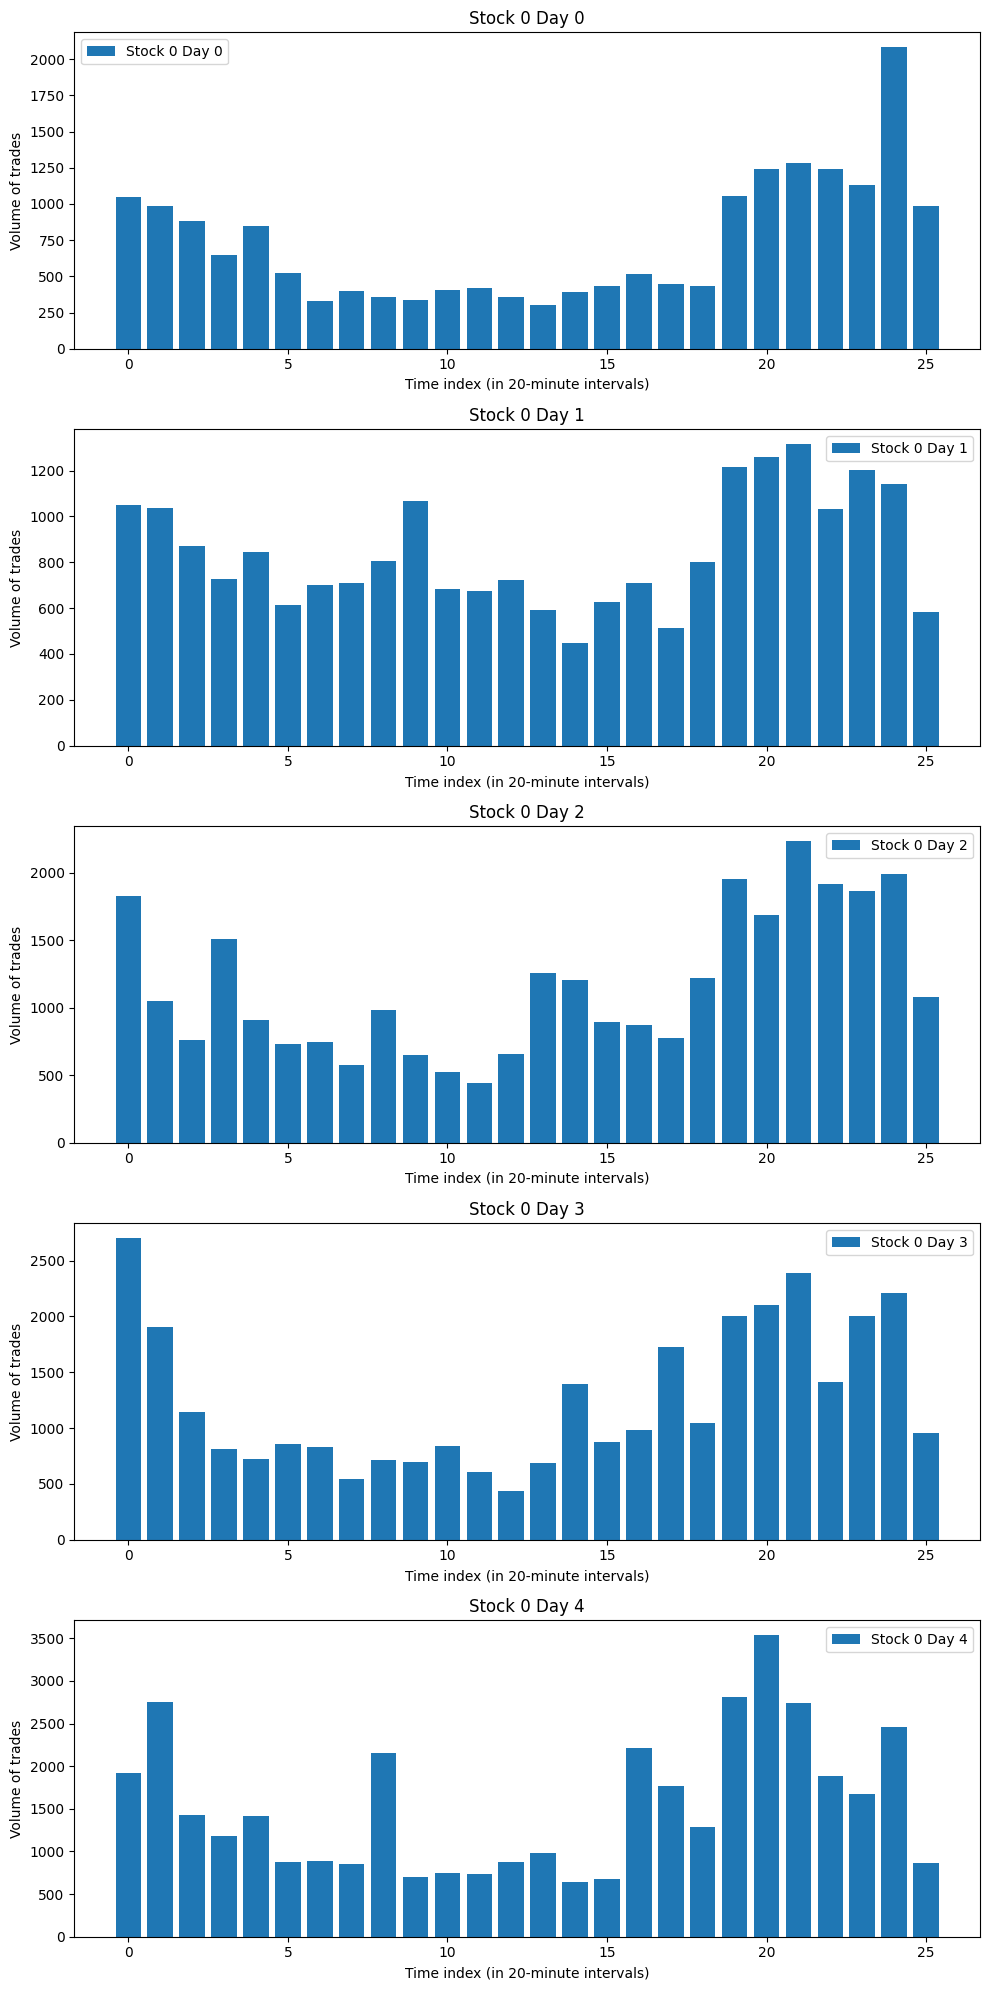

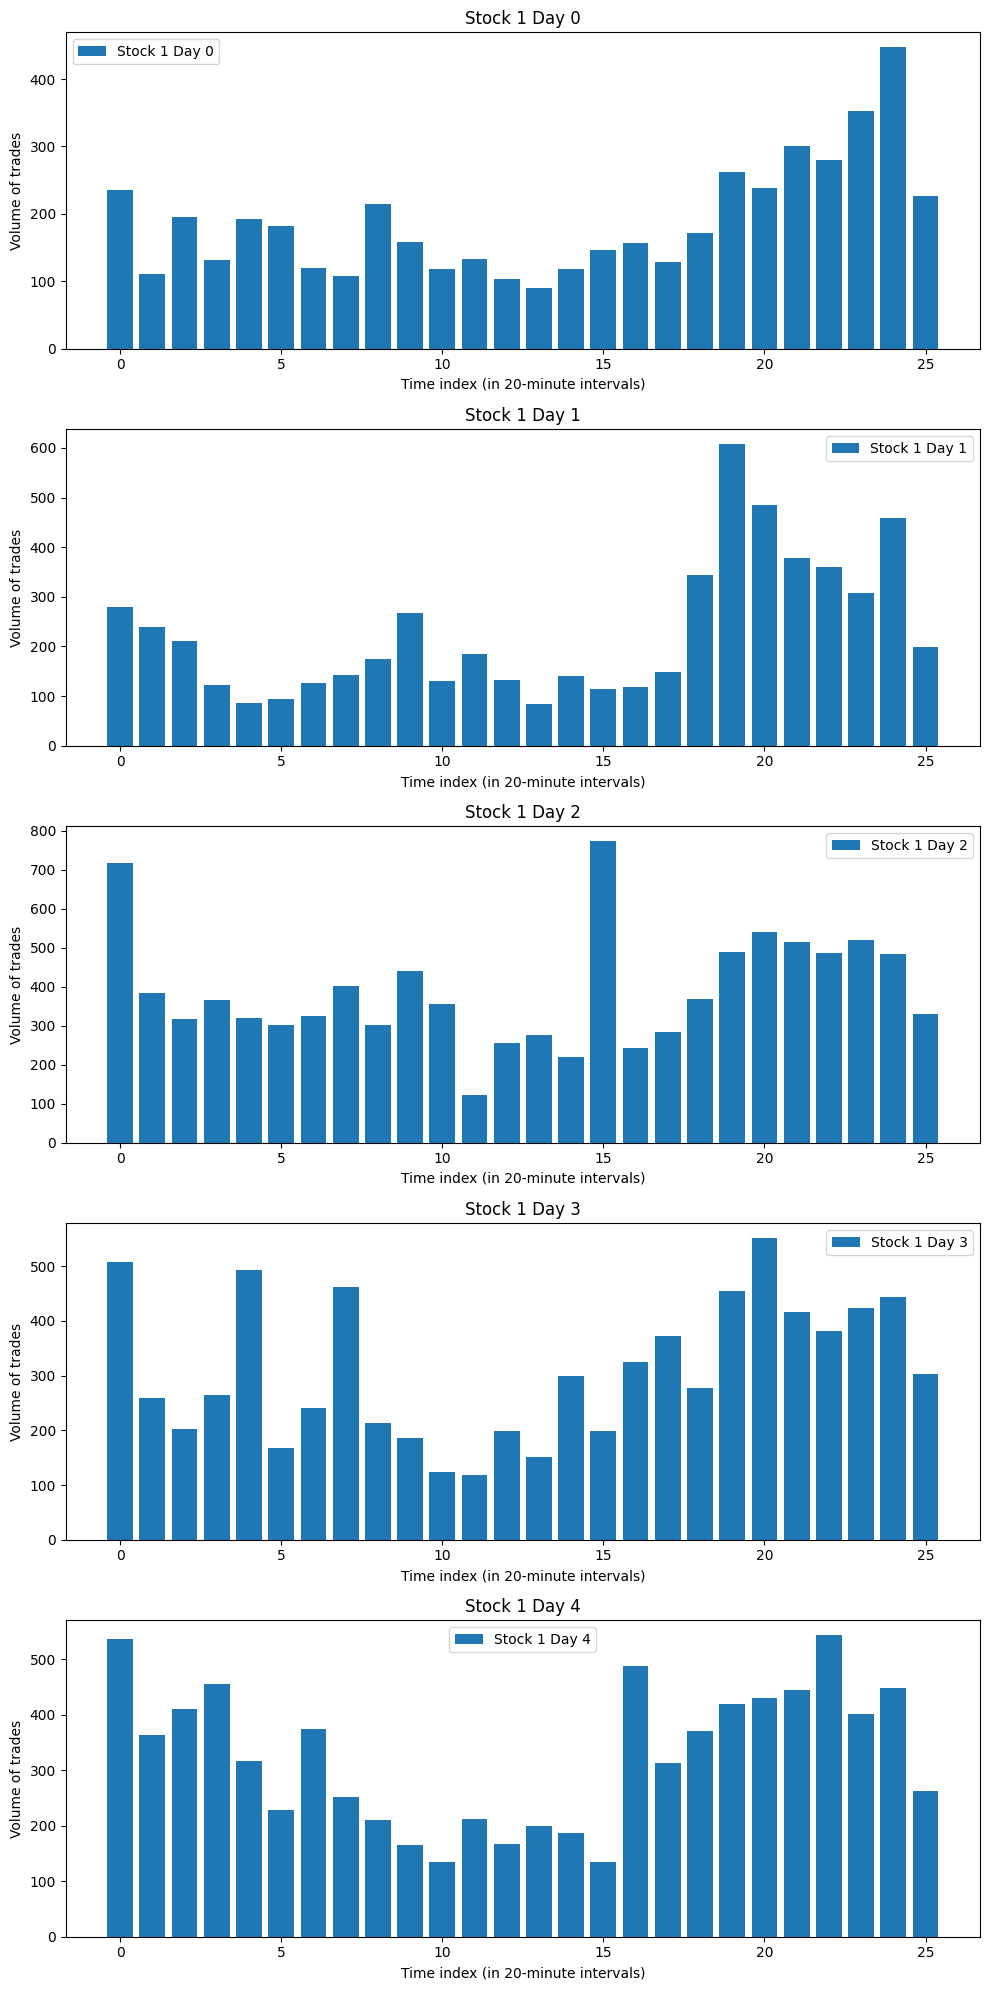

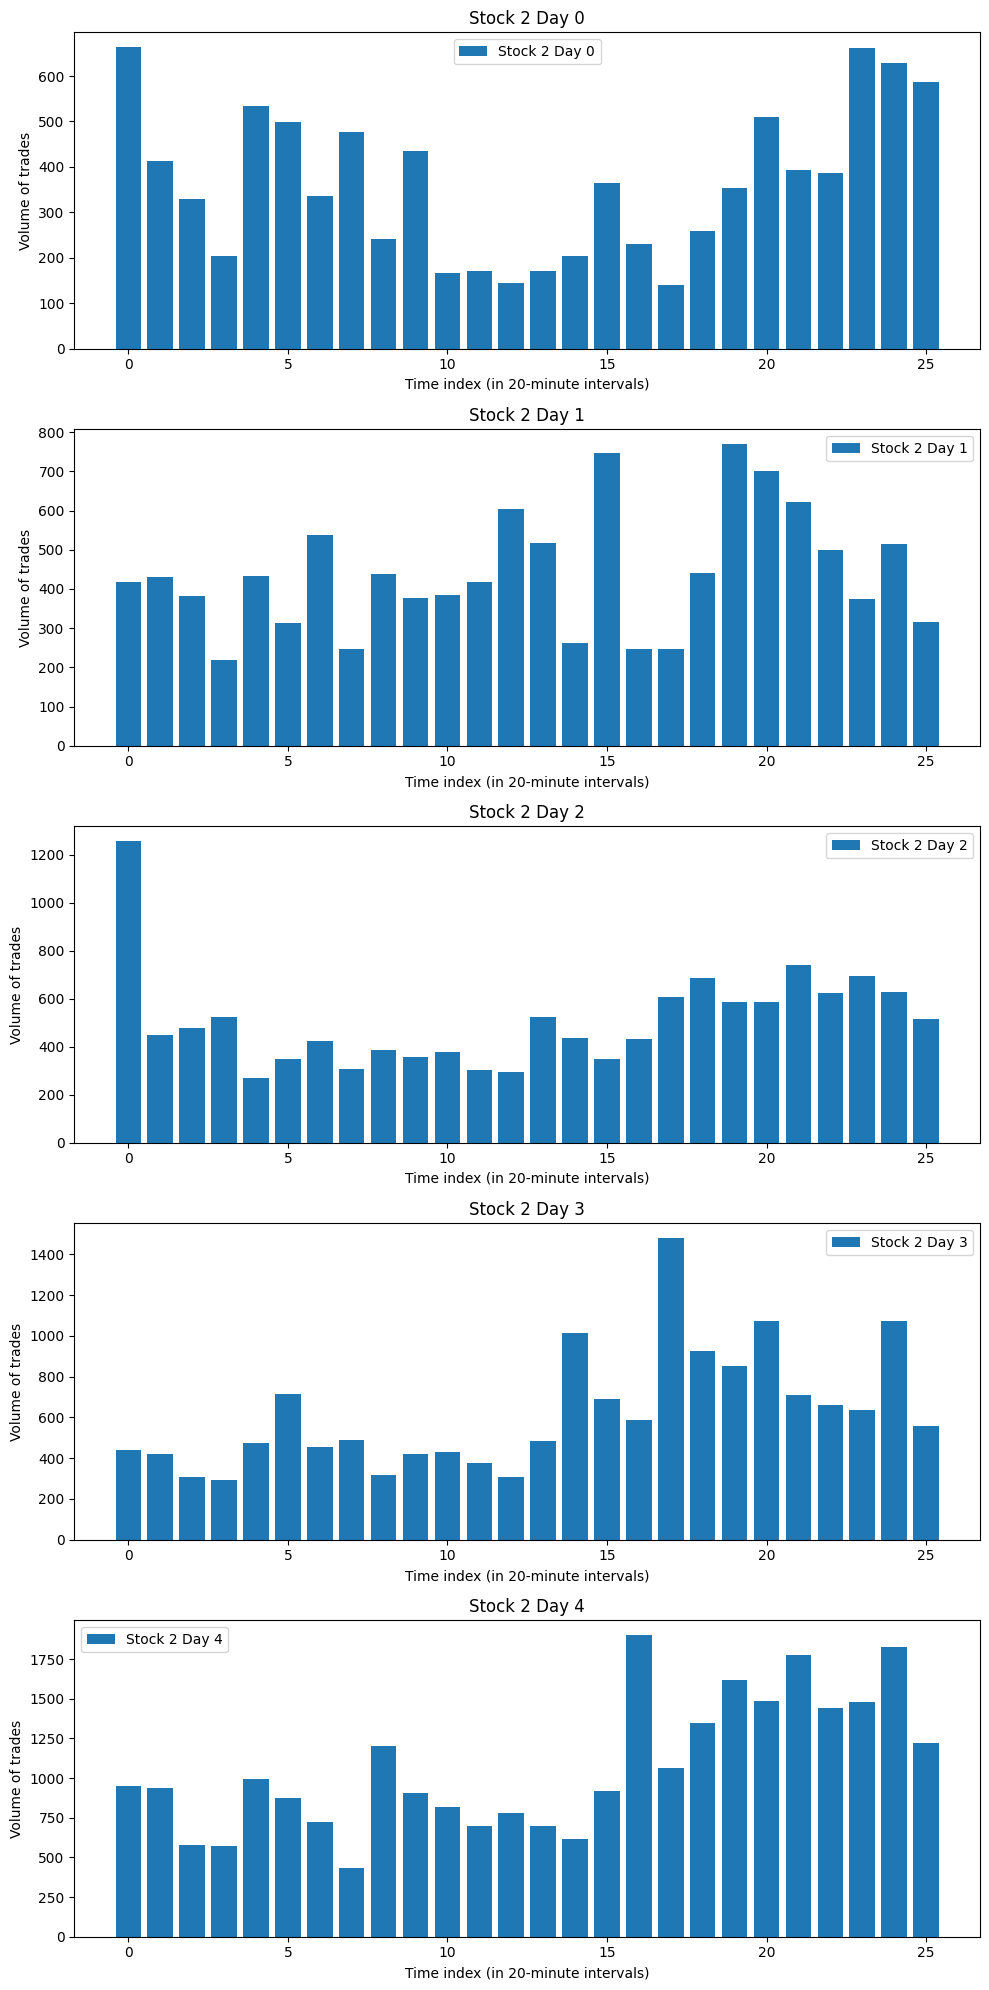

In [11]:
window = 20  # In minutes

for stock_id in stock_ids :
    print("\n")
    fig, axes = plt.subplots(len(day_ids), 1, figsize=(10, 4*len(day_ids)))
    for k, day_id in enumerate(day_ids) :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        timestamps = [j for j in range (int((df_trades["ts"].max() - df_trades["ts"].min()).total_seconds() / (window*60)) + 1)] 
        prices_volume = [0] * (int((df_trades["ts"].max() - df_trades["ts"].min()).total_seconds() / (window*60)) + 1)
        for i, ts in enumerate(df_trades["ts"]):
            index = int((ts - df_trades["ts"].min()).total_seconds() / (window*60))
            prices_volume[index] += 1
        axes[k].bar(timestamps, prices_volume, label = f"Stock {stock_id} Day {day_id}")
        axes[k].set_title(f"Stock {stock_id} Day {day_id}")
        axes[k].set_xlabel(f"Time index (in {window}-minute intervals)")
        axes[k].set_ylabel("Volume of trades")
        axes[k].legend()
    plt.tight_layout()
    plt.show()

To compute those graphs, we chose a time window, and counted all events that were within each time intervals. The shapes obtained are not as close as U-shapes as expected. We still some volume spikes at the beginning and end of each day for each stock, but the number of transactions is not as high as expected compared to the rest of the day.

___

### Moving average (optional) :

In [12]:
def moving_average_event(df, window = 5):
    series = df["price"].copy()
    ma_event_series = df["price"].copy()
    L = len(series)
    for i in range(window-1, L):
        ma_event_series.iloc[i] = series.iloc[i-window+1:i+1].mean()
    return(ma_event_series)

### Daily prices for each stock

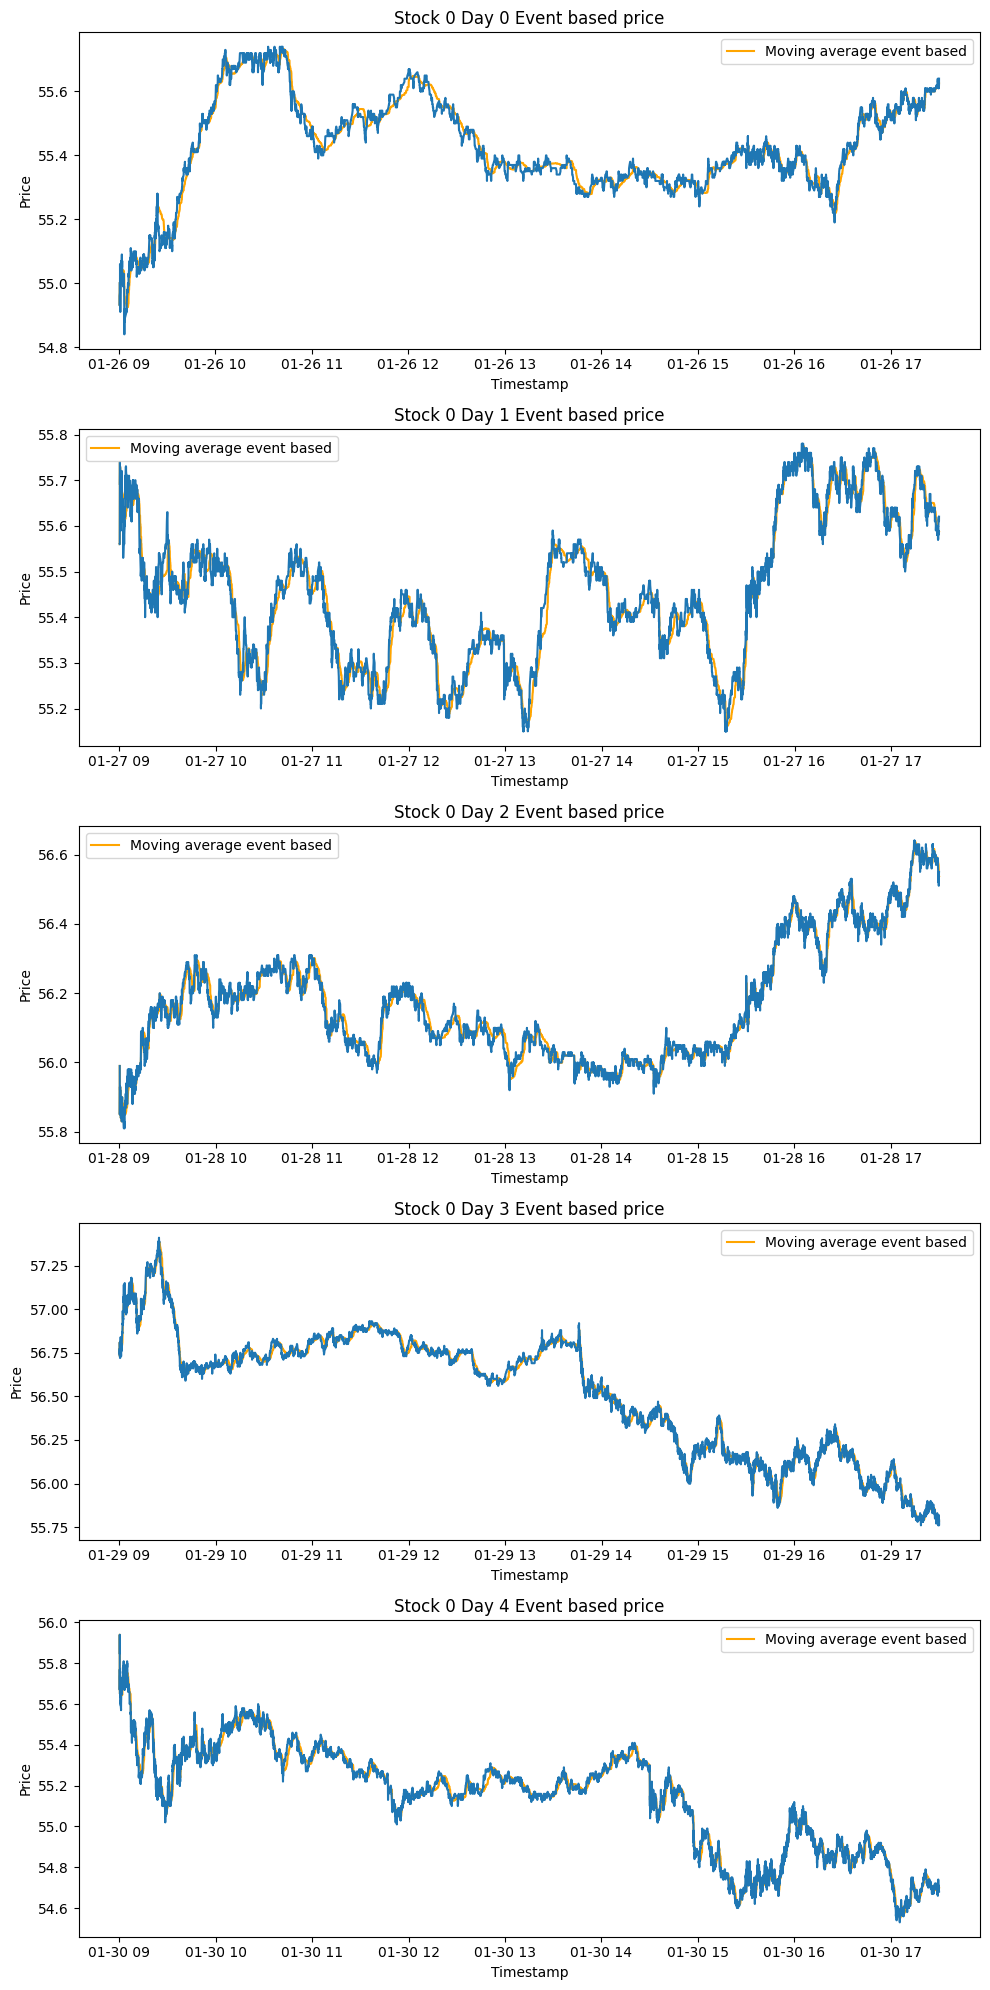

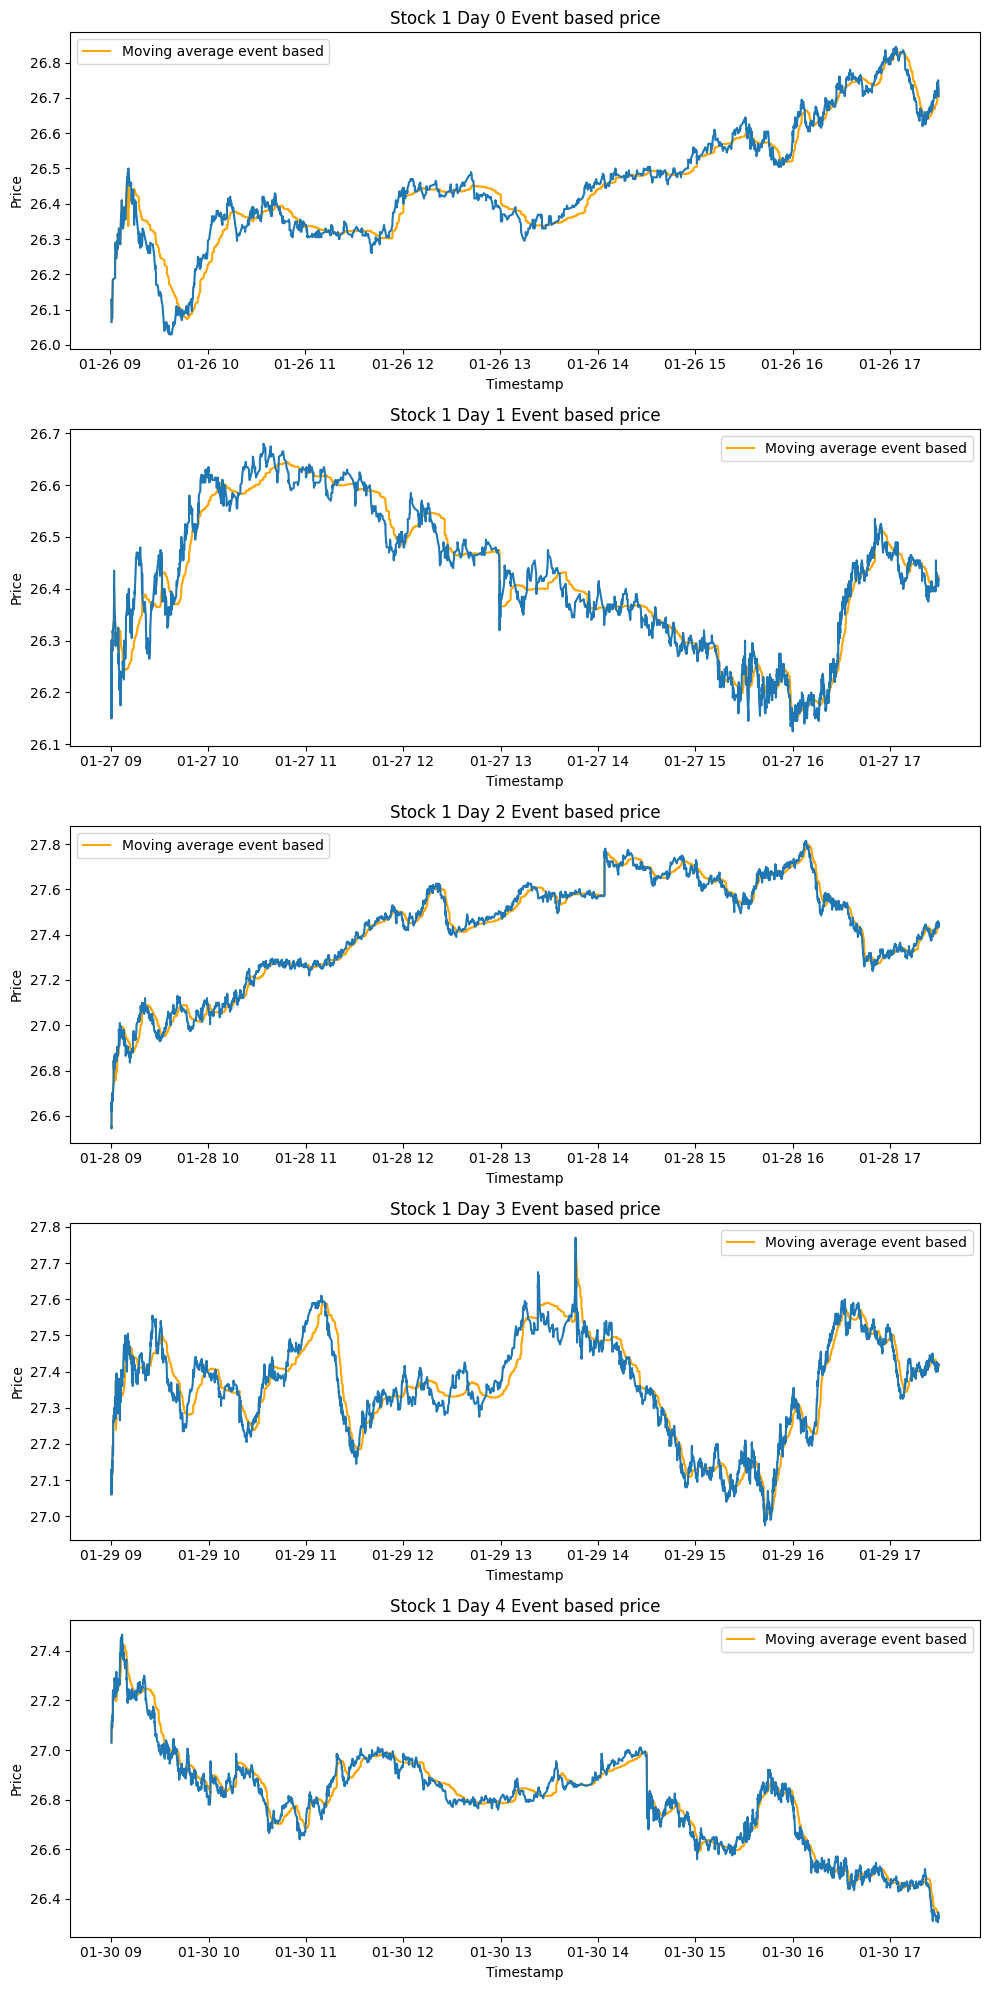

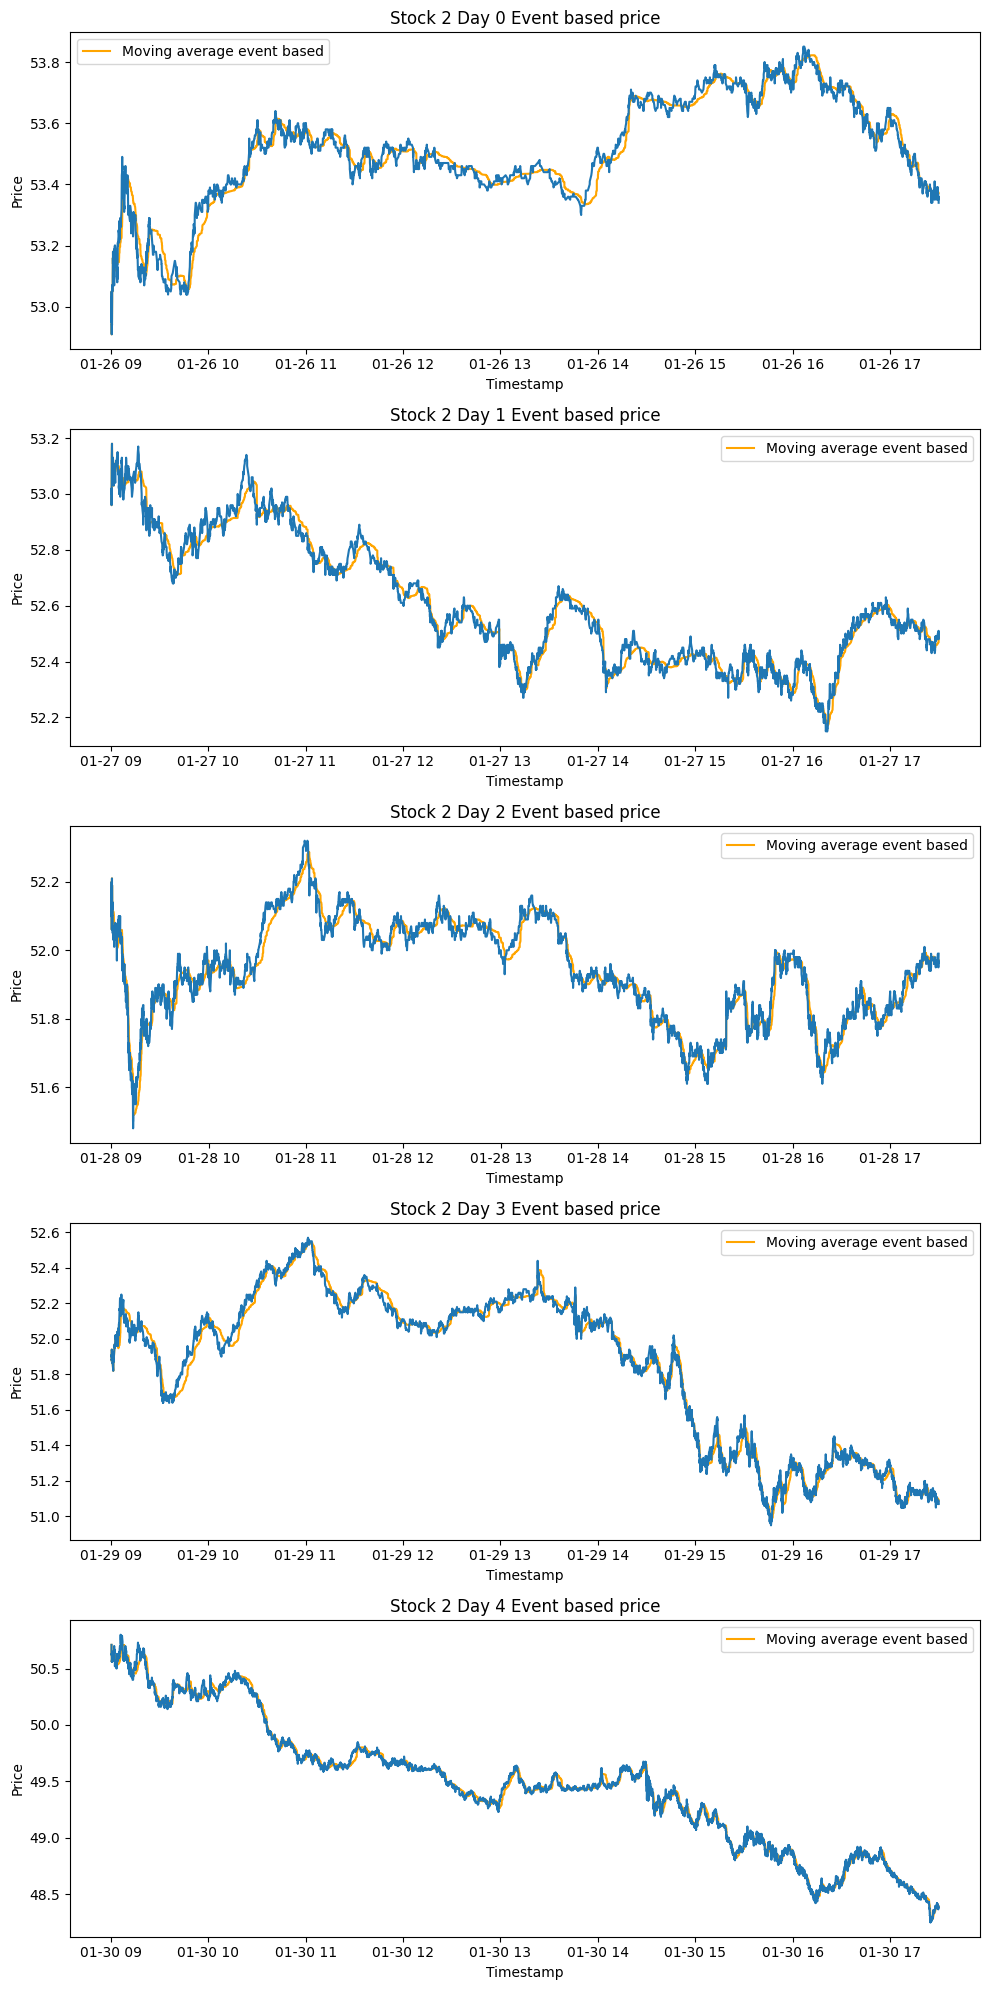

In [13]:
window = 100  # In events

for stock_id in stock_ids :
    print("\n")
    fig, axes = plt.subplots(len(day_ids), 1, figsize=(10, 4*len(day_ids)))
    for k, day_id in enumerate(day_ids) :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = df_trades["price"].copy()
        timestamps = df_trades["ts"].copy()
        ma_prices_event_based = moving_average_event(df_trades, window)
        axes[k].plot(timestamps, ma_prices_event_based, label = f"Moving average event based", color="orange")
        axes[k].plot(timestamps, prices)
        axes[k].set_title(f"Stock {stock_id} Day {day_id} Event based price")
        axes[k].set_xlabel("Timestamp")
        axes[k].set_ylabel("Price")
        axes[k].legend()
    plt.tight_layout()
    plt.show()

##### $\underline{\text{N.B. :}}$ 

This moving average is event-based and not time-based : when lots of trades (high liquidity) occur in the same time window, the moving average will be much closer to the true value of the stock price.

___

We can also compute the time-based covariance matrix based on a given time step between the stocks. It will use $\it{\text{net returns}}$ for the time-series.

To obtain the discrete time-based values of each stock $p_n$, we will take the first quote price (for each stock, for each day) after $nT$ with $T$ being our time step size.

Since we want them to have the same number of values across all the stocks within each day, we will use a function that takes the first order-based value after time $t$ has been reached.

$\underline{\text{plot}}$ variable will trigger or not the plots of time-based stock prices based on this method. The results obtained from the plots is that the stock prices are correctly obtained from this event-time conversion method.

In [14]:
def min_time_index(k,t_step,df,min_time=32400,initial_step=0): #Min time is 9:00:00, which corresponds to 32400 seconds after midnight
        for j in range(initial_step, len(df["ts"])):
            time = df["ts"].iloc[j]
            time_second = time.second + time.minute*60 + time.hour*3600
            if time_second >= k*t_step + min_time:
                return(j)
        print("This should not occur, error at min_time computation")
        return(None)


 --- Day 0 --- 


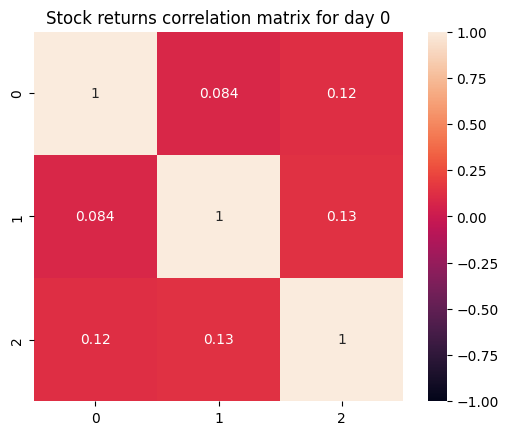


 --- Day 1 --- 


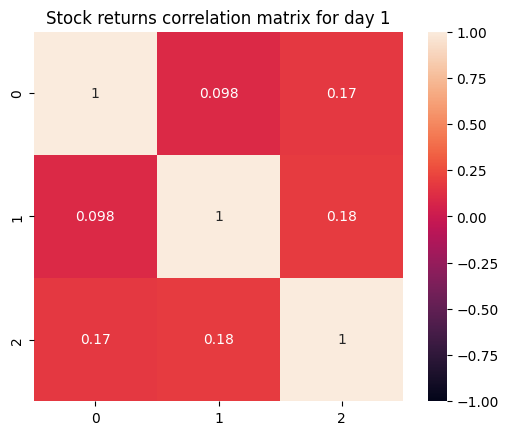


 --- Day 2 --- 


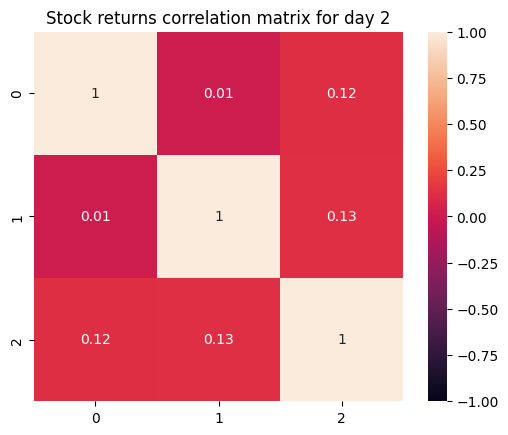


 --- Day 3 --- 


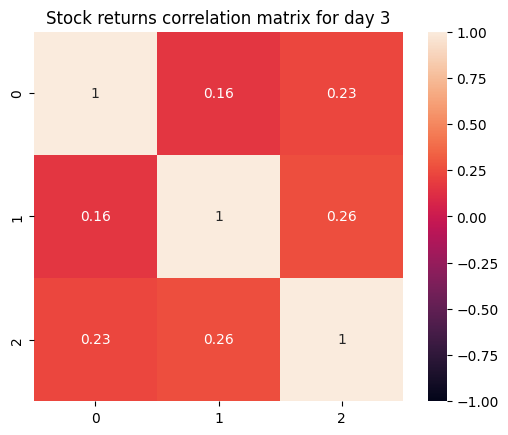


 --- Day 4 --- 


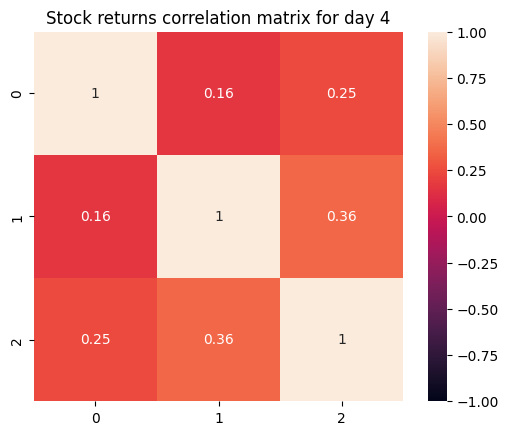

In [15]:
time_based_correlation_matrix = True

if time_based_correlation_matrix:
    t_step = 5 # seconds
    plot = False

    time_based_prices_vector_days = []
    prices_sizes = []

    for day_id in day_ids :
        time_based_prices_vector = [] # To store the time-based prices for each stock
        N = np.inf # To store the max common lenght of prices
        for stock_id in stock_ids :
            df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
            prices = df_trades["price"].copy()
            timestamps = df_trades["ts"].copy()
            time_based_prices = []
            time_based_timestamps = []
            k = int((max(timestamps)-min(timestamps)).total_seconds()/t_step)
            t = 0
            for i in range (k):
                t = min_time_index(i,t_step,df_trades,initial_step=t)
                time_based_prices.append(prices.iloc[t])
                time_based_timestamps.append(timestamps.iloc[t])
            if plot:
                plt.plot(time_based_timestamps, time_based_prices, label = f"Stock {stock_id}")
                plt.title(f"Stock {stock_id} Day {day_id} Time-based price")
                plt.xlabel("Timestamp")
                plt.ylabel("Price")
                plt.legend()
                plt.show()
            time_based_prices_vector.append(np.array(time_based_prices))
            N = min(N,k) # To make sure all price series have the same number of elements
        time_based_prices_vector_days.append(time_based_prices_vector)
        prices_sizes.append(N)

    for day_id in day_ids :
        idx = day_ids.index(day_id)
        print(f"\n --- Day {day_id} --- ")
        stock1_returns = time_based_prices_vector_days[idx][0][:prices_sizes[idx]-1] / time_based_prices_vector_days[idx][0][1:prices_sizes[idx]] - 1
        stock2_returns = time_based_prices_vector_days[idx][1][:prices_sizes[idx]-1] / time_based_prices_vector_days[idx][1][1:prices_sizes[idx]] - 1
        stock3_returns = time_based_prices_vector_days[idx][2][:prices_sizes[idx]-1] / time_based_prices_vector_days[idx][2][1:prices_sizes[idx]] - 1
        returns = np.array([stock1_returns, stock2_returns, stock3_returns])
        correlation_matrix = np.corrcoef(returns)
        sns.heatmap(correlation_matrix, annot=True, vmin = -1, vmax = 1, xticklabels=stock_ids, yticklabels=stock_ids, square = True)
        plt.title(f"Stock returns correlation matrix for day {day_id}")
        plt.show()      



From those correlation matrices we can see that stock 0 and stock 1 are mostly uncorrelated, and that stock 2 has higher correlation with stock 1 (up to 0.36 on day 4, Friday) than with stock 0 (up to 0.25 on day 4).

___

## Question 1.2 :

We computed daily tick sizes for each stock, and obtained :

Stock 0 tick size : $0.0100$

Stock 1 tick size : $0.0050$

Stock 2 tick size : $0.0100$ for each day but friday, where it fell to $0.0050$.

Those tick sizes are linked to the traded prices of each stock for each day, as prices above 50€ (and below another value not reached, seemingly 100€) require a tick size of 0.01, and prices below 50€ (and above another value not reached, seemingly 25€) require a tick size of 0.005.

The minimum price of stock 2 was above 50€ everyday but on the friday when it fell below 50€, thus the change of tick size.

In [16]:
for stock_id in stock_ids :
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = df_trades["price"].copy()
        prices = set(list(df_trades["price"].copy()))
        prices = sorted(list(prices))
        price_diffs = []
        for i in range (1, len(prices)) :
            price_diff = prices[i] - prices[i-1]
            price_diffs.append(price_diff)
        prices = df_trades["price"].copy()
        print(f"Stock {stock_id} Day {day_id} \t Tick size : {min(price_diffs):.4f} \t Maximum quote price : {prices.max():.4f} \t Minimum quote price : {prices.min():.4f}")



Stock 0 Day 0 	 Tick size : 0.0100 	 Maximum quote price : 55.7400 	 Minimum quote price : 54.8400
Stock 0 Day 1 	 Tick size : 0.0100 	 Maximum quote price : 55.7800 	 Minimum quote price : 55.1500
Stock 0 Day 2 	 Tick size : 0.0100 	 Maximum quote price : 56.6400 	 Minimum quote price : 55.8100
Stock 0 Day 3 	 Tick size : 0.0100 	 Maximum quote price : 57.4100 	 Minimum quote price : 55.7600
Stock 0 Day 4 	 Tick size : 0.0100 	 Maximum quote price : 55.9400 	 Minimum quote price : 54.5300


Stock 1 Day 0 	 Tick size : 0.0050 	 Maximum quote price : 26.8450 	 Minimum quote price : 26.0300
Stock 1 Day 1 	 Tick size : 0.0050 	 Maximum quote price : 26.6800 	 Minimum quote price : 26.1250
Stock 1 Day 2 	 Tick size : 0.0050 	 Maximum quote price : 27.8150 	 Minimum quote price : 26.5450
Stock 1 Day 3 	 Tick size : 0.0050 	 Maximum quote price : 27.7700 	 Minimum quote price : 26.9750
Stock 1 Day 4 	 Tick size : 0.0050 	 Maximum quote price : 27.4650 	 Minimum quote price : 26.3050


Stoc

___

## Question 1.3 :

For the intraday activity, we measured the number of transactions (not the transaction volume) for each stock for each day :



In [17]:
for stock_id in stock_ids :
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        print(f"Stock {stock_id} Day {day_id} \t Total daily number of trades : {len(df_trades)}")



Stock 0 Day 0 	 Total daily number of trades : 19076
Stock 0 Day 1 	 Total daily number of trades : 21933
Stock 0 Day 2 	 Total daily number of trades : 30315
Stock 0 Day 3 	 Total daily number of trades : 32581
Stock 0 Day 4 	 Total daily number of trades : 40058


Stock 1 Day 0 	 Total daily number of trades : 4927
Stock 1 Day 1 	 Total daily number of trades : 5941
Stock 1 Day 2 	 Total daily number of trades : 10144
Stock 1 Day 3 	 Total daily number of trades : 8038
Stock 1 Day 4 	 Total daily number of trades : 8472


Stock 2 Day 0 	 Total daily number of trades : 9500
Stock 2 Day 1 	 Total daily number of trades : 11466
Stock 2 Day 2 	 Total daily number of trades : 13178
Stock 2 Day 3 	 Total daily number of trades : 16186
Stock 2 Day 4 	 Total daily number of trades : 27879


The stock 0 and stock 2 were much more traded than stock 1, having an increasing number of realized trades as the week went by. Intraday trading activity being higher on friday than monday can be explained with exotic options reaching maturity on friday requiring execution of trades on the last day of the week.

However, for the spike of trading activity on Wednesday for stock 1, it can be explained by a sudden spike in the stock price (caused by a financial event) on that day : 

It ranged in $[26.125, 26.68]$ on Tuesday
It increased to $[26.545, 27.815]$ on Wednesday

This sudden increase in the stock price may have interest investors to take the opportunity to make profits (some trading signals might have been triggered).

___

## Question 1.4 :

We look at the traded volume for each stock for each day. Since we already know the number of transactions, we can then compute the mean traded volume per event. 





Stock 0 Day 0 	 Total daily number of trades : 19076
Stock 0 Day 0 	 Daily volatility : 0.1654
Stock 0 Day 0 	 Total daily volume of trades : 2574521
Stock 0 Day 0 	 Daily mean traded volume for each day : 134.96

Stock 0 Day 1 	 Total daily number of trades : 21933
Stock 0 Day 1 	 Daily volatility : 0.1610
Stock 0 Day 1 	 Total daily volume of trades : 2449507
Stock 0 Day 1 	 Daily mean traded volume for each day : 111.68

Stock 0 Day 2 	 Total daily number of trades : 30315
Stock 0 Day 2 	 Daily volatility : 0.1900
Stock 0 Day 2 	 Total daily volume of trades : 4346132
Stock 0 Day 2 	 Daily mean traded volume for each day : 143.37

Stock 0 Day 3 	 Total daily number of trades : 32581
Stock 0 Day 3 	 Daily volatility : 0.4015
Stock 0 Day 3 	 Total daily volume of trades : 4171415
Stock 0 Day 3 	 Daily mean traded volume for each day : 128.03

Stock 0 Day 4 	 Total daily number of trades : 40058
Stock 0 Day 4 	 Daily volatility : 0.2767
Stock 0 Day 4 	 Total daily volume of trades :

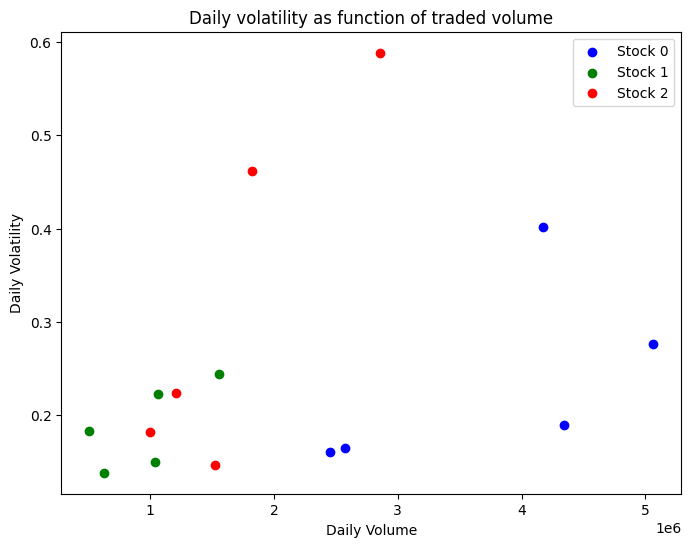

In [18]:
colors = ["blue","green","red"]
qty_lists = []
vol_lists = []
for stock_id in stock_ids :
    qty_list = []
    vol_list = []
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = df_trades["price"].copy()
        quantities = df_trades["qty"].copy()
        volatility = prices.std()
        qty_list.append(sum(quantities))
        vol_list.append(volatility)
        print(f"\nStock {stock_id} Day {day_id} \t Total daily number of trades : {len(quantities)}")
        print(f"Stock {stock_id} Day {day_id} \t Daily volatility : {volatility:.4f}")
        print(f"Stock {stock_id} Day {day_id} \t Total daily volume of trades : {sum(quantities)}")
        print(f"Stock {stock_id} Day {day_id} \t Daily mean traded volume for each day : {sum(quantities)/len(quantities):.2f}")
    qty_lists.append(qty_list)
    vol_lists.append(vol_list)

plt.figure(figsize=(8,6))
for i in range (len(qty_lists)):
    plt.scatter(qty_lists[i],vol_lists[i],color = colors[i],label = f"Stock {i}")
plt.title("Daily volatility as function of traded volume")
plt.xlabel("Daily Volume")
plt.ylabel("Daily Volatility")
plt.legend()
plt.show()



We can observe that the quantities traded each day match the number of trades, which was expected : when more trades occur, given that the average number of trades is around 100 (which is more or less verified for every stock, every day), more volume is exchanged.

The sudden spike for stock 1 on day 2 (Wednesday) is also being observed on the total volume traded that day, which was also expected.

The link between volatility and traded volume is that they are positively correlated, which was again expected :

When there is a lot of volume exchanged, prices tend to change as some price range from the Limit Order Book may disappear from some trades with big quantities. Here, it can be observed on the scattered plot, with the volatility points being (mostly) higher when the volume is higher. 

___

## Question 1.5 :

We will first start with event-based log-returns, simply by computing :

$ r_{t+1} = \ln (\dfrac{P_{t+1}}{P_t})  = \ln (P_{t+1}) - \ln (P_t) $, with the indices $t$ representing event time.

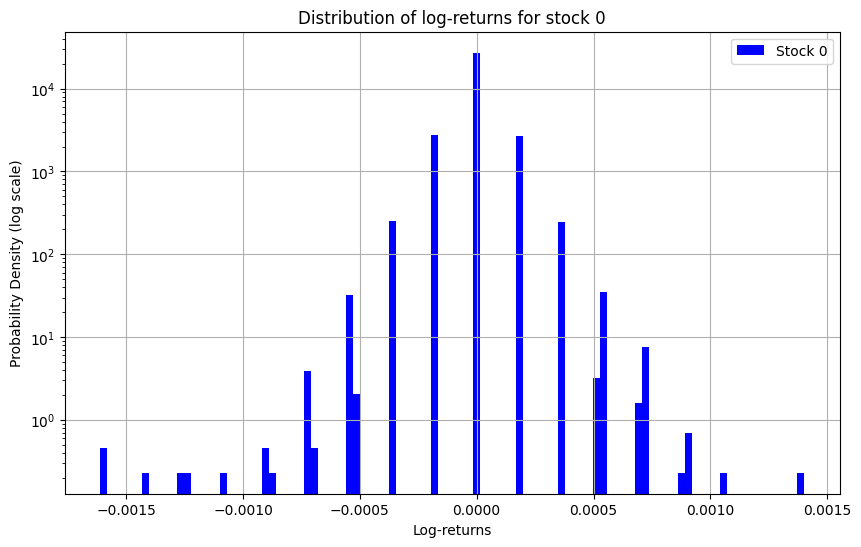

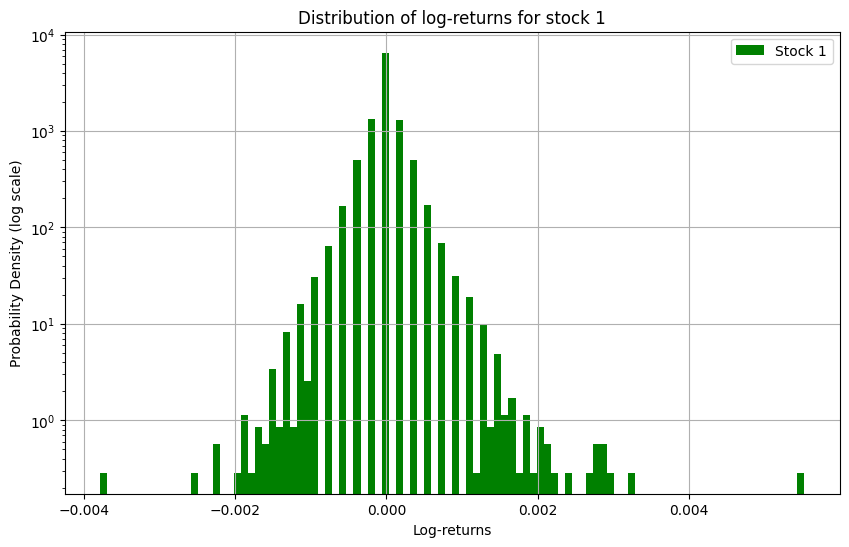

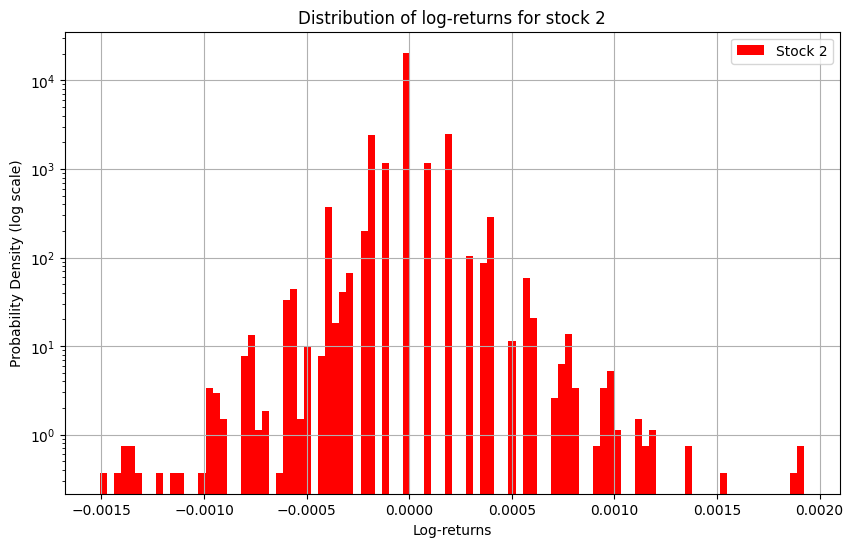

In [19]:
colors = ["blue","green","red"]
log_returns_lists = []
for stock_id in stock_ids :
    log_return_list = []
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = df_trades["price"].copy()
        log_prices = np.log(prices)
        log_returns = log_prices.diff().dropna()
        log_return_list.append(log_returns)
    log_return_list = pd.concat(log_return_list)
    log_returns_lists.append(log_return_list)

for i,log_return_list in enumerate(log_returns_lists):
    plt.figure(figsize=(10,6))
    log_return_list.hist(bins=100,density=True,color=colors[i],label = f"Stock {i}")
    plt.title(f"Distribution of log-returns for stock {i}")
    plt.yscale("log")
    plt.xlabel("Log-returns")
    plt.ylabel("Probability Density (log scale)")
    plt.legend()
    plt.show()



What we can observe, is that since the prices reached are discrete (because of tick size), the log returns distribution is also discrete, thus the gaps when plotting the density functions. 

There are also some higher densities on the end of both tails, as sometimes the volume traded will move the traded price for more than several tick sizes when big volumes traded, thus the distribution on the sides.

The expected result was obtained : most of the time, the price doesn't change from the trades (not enough volume to empty the whome volume for a single bid/asked price), but when it does, it tends to be limited to several tick sizes (most of the time), thus obtaining a distribution that looks like a gaussian with discrete step size.  

___

When computing in calendar time, we expect a gaussian distribution as well, however this time we do not expect a discrete distribution as the time weight will in principle convert the discrete distribution of log returns into a continuous distribution.

We will compute :

$ r_{t+1} = \Delta T _{t+1} \ln (\dfrac{P_{t+1}}{P_t})  = \Delta T _{t+1} (\ln (P_{t+1}) - \ln (P_t)) $, with the indices $t$ representing event time.

$ \Delta T _{t+1} = T_{t+1} - T_t $

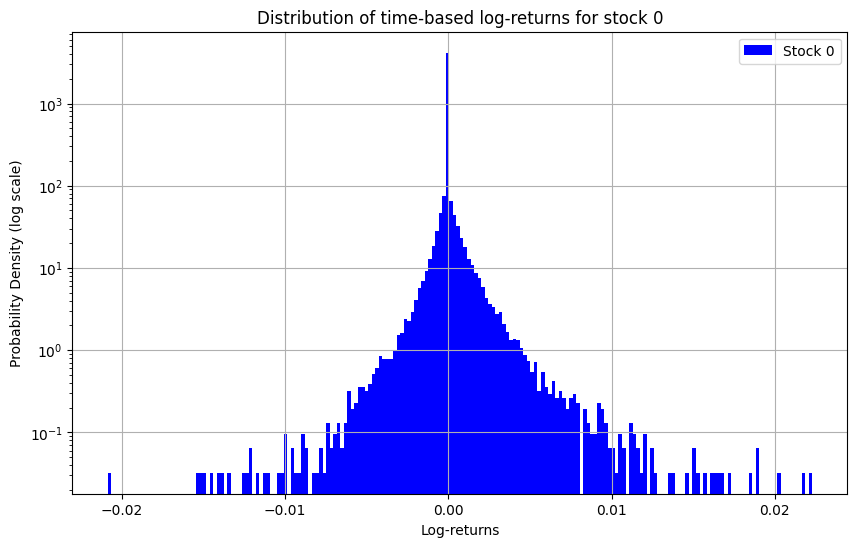

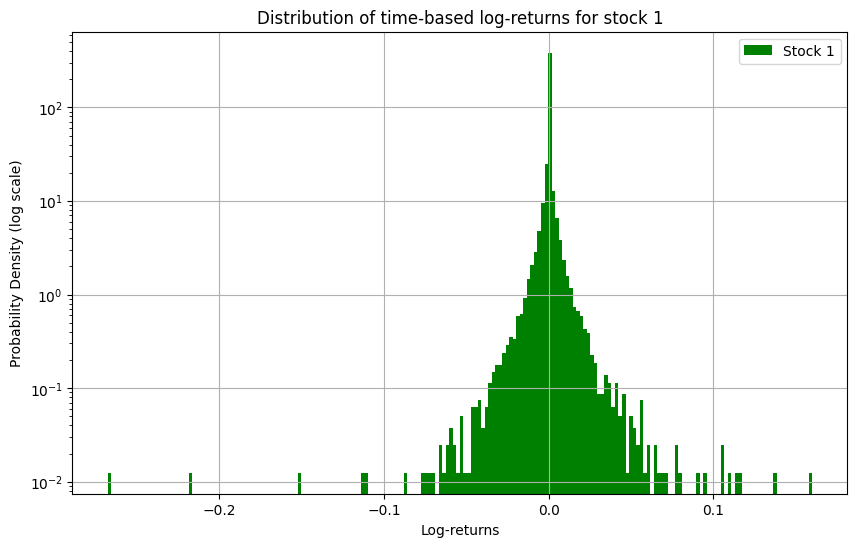

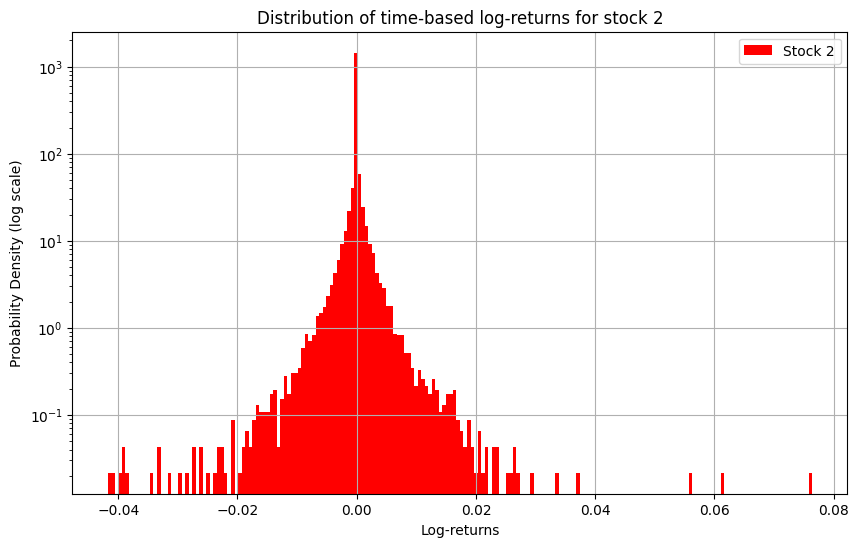

In [20]:
colors = ["blue","green","red"]
time_log_returns_lists = []
for stock_id in stock_ids :
    time_log_return_list = []
    print("\n")
    for day_id in day_ids :
        df_trades = trades[stock_ids.index(stock_id), day_ids.index(day_id)]
        prices = df_trades["price"].copy()
        log_prices = np.log(prices)
        log_returns = log_prices.diff().dropna()
        delta_T = df_trades["ts"].copy().diff().dt.total_seconds()
        time_weighted_log_returns = delta_T*log_returns
        time_log_return_list.append(time_weighted_log_returns)
    time_log_return_list = pd.concat(time_log_return_list)
    time_log_returns_lists.append(time_log_return_list)


for i,time_log_return_list in enumerate(time_log_returns_lists):
    plt.figure(figsize=(10,6))
    time_log_return_list.hist(bins=200,density=True,color=colors[i],label = f"Stock {i}")
    plt.title(f"Distribution of time-based log-returns for stock {i}")
    plt.yscale("log")
    plt.xlabel("Log-returns")
    plt.ylabel("Probability Density (log scale)")
    plt.legend()
    plt.show()



We correctly obtain a more continuous gaussian distribution, as expected.

___

## 2. Quotes

This section focuses on the analysis of the quotes (updates) data, which describe the evolution of the limit order book over time. Using these data, we study price dynamics, spread behavior, and order book imbalance at high frequency, and investigate their relationship with subsequent mid-price movements.


### 2.1 Dataset — General statistical checks (Quotes / Updates)

We perform basic descriptive checks on the **quotes (updates)** data for **all stocks and all days**.  
For each `(stock, day)` file, we compute:

- **Number of quote updates** (row count)
- **Trading time span**: first timestamp, last timestamp, and total duration + its distribution to see if we have outliers
- **Summary statistics** (count / mean)
  - best bid price, best ask price
  - mid-price
  - spread
  - best bid size, best ask size

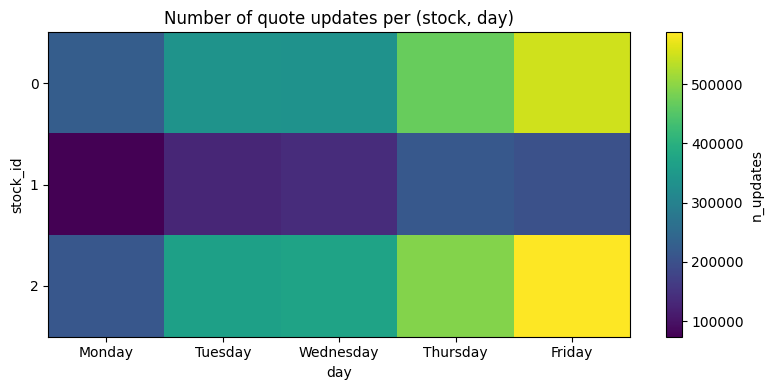


=== Stock 0 ===


,day,n_updates,duration_hhmm,bp_mean,ap_mean,mid_mean,bq_mean,aq_mean,spread_median
0,Monday,226217,08:29,55.4160,55.4291,55.4225,686.65,938.35,0.01
1,Tuesday,338090,08:30,55.4711,55.4846,55.4778,636.47,683.19,0.01
2,Wednesday,334977,08:30,56.1914,56.2046,56.1980,744.39,997.28,0.01
3,Thursday,468433,08:30,56.4135,56.4277,56.4206,632.36,625.27,0.01
4,Friday,550083,08:30,55.0695,55.0839,55.0767,634.55,671.05,0.01



=== Stock 1 ===


,day,n_updates,duration_hhmm,bp_mean,ap_mean,mid_mean,bq_mean,aq_mean,spread_median
0,Monday,73947,08:29,26.4759,26.4893,26.4826,367.62,420.09,0.010
1,Tuesday,128253,08:29,26.3530,26.3673,26.3601,383.21,399.62,0.015
2,Wednesday,139805,08:30,27.4109,27.4249,27.4179,488.12,533.57,0.015
3,Thursday,214988,08:30,27.3401,27.3557,27.3479,460.27,463.45,0.015
4,Friday,201558,08:30,26.7695,26.7853,26.7774,522.39,428.28,0.015



=== Stock 2 ===


,day,n_updates,duration_hhmm,bp_mean,ap_mean,mid_mean,bq_mean,aq_mean,spread_median
0,Monday,212731,08:29,53.5405,53.5550,53.5478,587.33,622.25,0.010
1,Tuesday,365027,08:30,52.5279,52.5433,52.5356,601.01,628.29,0.020
2,Wednesday,371879,08:30,51.9045,51.9199,51.9122,690.24,663.57,0.010
3,Thursday,491762,08:30,51.7084,51.7272,51.7178,650.50,576.35,0.020
4,Friday,587301,08:30,49.3185,49.3325,49.3255,389.57,333.18,0.015


,stock_id,min_start,mean_start,max_start
0,0,09:00:13.432150,09:00:20.819191,09:00:27.018202
1,1,09:00:00.860850,09:00:13.546627,09:00:24.775089
2,2,09:00:10.290301,09:00:19.864028,09:00:29.071890


In [21]:
DAY_NAMES = {"0": "Monday", "1": "Tuesday", "2": "Wednesday", "3": "Thursday", "4": "Friday"}

def hhmm_from_seconds(x):
    if pd.isna(x):
        return ""
    x = int(round(x))
    h = x // 3600
    m = (x % 3600) // 60
    return f"{h:02d}:{m:02d}"

def tod_str_us(ts):
    if pd.isna(ts):
        return ""
    return ts.strftime("%H:%M:%S.%f")  # microseconds

def seconds_since_midnight(ts):
    if pd.isna(ts):
        return np.nan
    return ts.hour * 3600 + ts.minute * 60 + ts.second + ts.microsecond / 1e6

def first_continuous_timestamp(df):
    df = df.sort_values("ts").reset_index(drop=True)
    ts = pd.to_datetime(df["ts"])
    mask = df["bp"].notna() & df["ap"].notna()
    if not mask.any():
        return pd.NaT
    return ts.loc[mask].iloc[0]

def summarize_updates(df, stock_id, day_id):
    df = df.sort_values("ts").reset_index(drop=True)
    ts = pd.to_datetime(df["ts"])
    n = int(len(df))

    t_first = ts.iloc[0] if n > 0 else pd.NaT
    t_last = ts.iloc[-1] if n > 0 else pd.NaT
    duration_s = (t_last - t_first).total_seconds() if n > 1 else np.nan

    bp = pd.to_numeric(df["bp"], errors="coerce")
    ap = pd.to_numeric(df["ap"], errors="coerce")
    bq = pd.to_numeric(df["bq"], errors="coerce")
    aq = pd.to_numeric(df["aq"], errors="coerce")

    mid = 0.5 * (bp + ap)
    spread = ap - bp

    return {
        "stock_id": str(stock_id),
        "day_id": str(day_id),
        "day": DAY_NAMES.get(str(day_id), str(day_id)),
        "n_updates": n,
        "duration_hhmm": hhmm_from_seconds(duration_s),
        "bp_mean": float(bp.mean()) if bp.count() > 0 else np.nan,
        "ap_mean": float(ap.mean()) if ap.count() > 0 else np.nan,
        "mid_mean": float(mid.mean()) if mid.count() > 0 else np.nan,
        "bq_mean": float(bq.mean()) if bq.count() > 0 else np.nan,
        "aq_mean": float(aq.mean()) if aq.count() > 0 else np.nan,
        "spread_median": float(spread.median()) if spread.count() > 0 else np.nan,
    }


def build_summary(updates, stock_ids, day_ids):
    rows = []
    for i, stock_id in enumerate(stock_ids):
        for j, day_id in enumerate(day_ids):
            rows.append(summarize_updates(updates[i, j], stock_id, day_id))
    return pd.DataFrame(rows).sort_values(["stock_id", "day_id"]).reset_index(drop=True)

def make_stock_tables(summary):
    tables = {}
    cols = [
        "day",
        "n_updates",
        "duration_hhmm",
        "bp_mean",
        "ap_mean",
        "mid_mean",
        "bq_mean",
        "aq_mean",
        "spread_median",
    ]

    for stock_id in sorted(summary["stock_id"].unique()):
        t = summary.loc[summary["stock_id"] == stock_id, cols].copy()
        t["bp_mean"] = t["bp_mean"].round(4)
        t["ap_mean"] = t["ap_mean"].round(4)
        t["mid_mean"] = t["mid_mean"].round(4)
        t["bq_mean"] = t["bq_mean"].round(2)
        t["aq_mean"] = t["aq_mean"].round(2)
        t["spread_median"] = t["spread_median"].round(4)
        tables[stock_id] = t.reset_index(drop=True)

    return tables

def plot_heatmap_n_updates(summary):
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    pivot = summary.pivot(index="stock_id", columns="day", values="n_updates").reindex(columns=day_order)

    plt.figure(figsize=(8, 4))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="n_updates")
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.xlabel("day")
    plt.ylabel("stock_id")
    plt.title("Number of quote updates per (stock, day)")
    plt.tight_layout()
    plt.show()

def build_start_stats_table(updates, stock_ids, day_ids):
    rows = []
    for i, stock_id in enumerate(stock_ids):
        starts_ts = [first_continuous_timestamp(updates[i, j]) for j in range(len(day_ids))]
        starts_sod = np.array([seconds_since_midnight(t) for t in starts_ts], dtype=float)

        if np.all(np.isnan(starts_sod)):
            rows.append({"stock_id": str(stock_id), "min_start": "", "mean_start": "", "max_start": ""})
            continue

        i_min = int(np.nanargmin(starts_sod))
        i_max = int(np.nanargmax(starts_sod))
        mean_sod = float(np.nanmean(starts_sod))

        mean_h = int(mean_sod // 3600)
        mean_sod -= 3600 * mean_h
        mean_m = int(mean_sod // 60)
        mean_sod -= 60 * mean_m
        mean_s = int(mean_sod)
        mean_us = int(round((mean_sod - mean_s) * 1e6))
        mean_str = f"{mean_h:02d}:{mean_m:02d}:{mean_s:02d}.{mean_us:06d}"

        rows.append(
            {
                "stock_id": str(stock_id),
                "min_start": tod_str_us(starts_ts[i_min]),
                "mean_start": mean_str,
                "max_start": tod_str_us(starts_ts[i_max]),
            }
        )

    return pd.DataFrame(rows).sort_values("stock_id").reset_index(drop=True)

summary_df = build_summary(updates, stock_ids, day_ids)

plot_heatmap_n_updates(summary_df)

stock_tables = make_stock_tables(summary_df)
for stock_id, table in stock_tables.items():
    print(f"\n=== Stock {stock_id} ===")
    display(table)

start_stats_df = build_start_stats_table(updates, stock_ids, day_ids)
display(start_stats_df)


Comments on statistics: 
- We can see that the quotes file is more "active" at the end of the week => this could be that long term investor equilibrate their positions on a weekly basis
- Stock 0 and stock 2 are more active
- All trading durations are approx 8:30 hours which is coherent
- ll spread medians are close to 1-3 ticks which corresponds to what we saw in class
- We can see that trading starts at approximatly 9:00 + a random time between 0 and 30 seconds, as we saw with trades in the first part.

Now we may look at if there are any issued with the dataset. 
We will check the following:
- Are Ask prices always higher than bid prices ? 
- Are there any negative ask / bids prices ?
- Are there any negatigve quantities ?
- Is timestamps increasing ?

In [22]:
def quality_stats_updates(df):
    ts = pd.to_datetime(df["ts"])
    bp = pd.to_numeric(df["bp"], errors="coerce")
    ap = pd.to_numeric(df["ap"], errors="coerce")
    bq = pd.to_numeric(df["bq"], errors="coerce")
    aq = pd.to_numeric(df["aq"], errors="coerce")

    both_prices = bp.notna() & ap.notna()

    return {
        "ask_lower_bid": int(((ap <= bp) & both_prices).sum()),
        "neg_bp": int((bp < 0).sum(skipna=True)),
        "neg_ap": int((ap < 0).sum(skipna=True)),
        "neg_bq": int((bq < 0).sum(skipna=True)),
        "neg_aq": int((aq < 0).sum(skipna=True)),
        "time_decreasing": int((ts.diff() < pd.Timedelta(0)).sum()),
    }


rows = []
for i, stock_id in enumerate(stock_ids):
    for j, day_id in enumerate(day_ids):
        rows.append(
            {
                "stock_id": str(stock_id),
                "day_id": str(day_id),
                **quality_stats_updates(updates[i, j]),
            }
        )

quality_summary = (
    pd.DataFrame(rows)
    .sort_values(["stock_id", "day_id"])
    .reset_index(drop=True)
)

display(quality_summary)

by_stock = (
    quality_summary
    .groupby("stock_id")[["ask_lower_bid", "neg_bp", "neg_ap", "neg_bq", "neg_aq", "time_decreasing"]]
    .sum()
    .reset_index()
)

display(by_stock)


,stock_id,day_id,ask_lower_bid,neg_bp,neg_ap,neg_bq,neg_aq,time_decreasing
0,0,0,0,0,0,0,0,2
1,0,1,0,0,0,0,0,0
2,0,2,0,0,0,0,0,2
3,0,3,0,0,0,0,0,2
4,0,4,1,0,0,0,0,1
5,1,0,0,0,0,0,0,0
6,1,1,0,0,0,0,0,0
7,1,2,0,0,0,0,0,1
8,1,3,0,0,0,0,0,0
9,1,4,0,0,0,0,0,0


,stock_id,ask_lower_bid,neg_bp,neg_ap,neg_bq,neg_aq,time_decreasing
0,0,1,0,0,0,0,7
1,1,0,0,0,0,0,1
2,2,0,0,0,0,0,3


It seems that we only have **one outlier for stock 0 on day 4**. 
- On one line the ask price is lower (or equal) than the bid price which is not coherent.

Otherwise it seems the dataset is free of any major issues.
- no negative prices nor quantities
- increasing timestamps

### 2.2 Plotting 5 minutes LOB 

We decided to plot: 
- Stock 0 (very active)
- Friday (most active day)
- Around the last 5 minutes of the day (generally the most active period of the day => U shaped we saw in class)


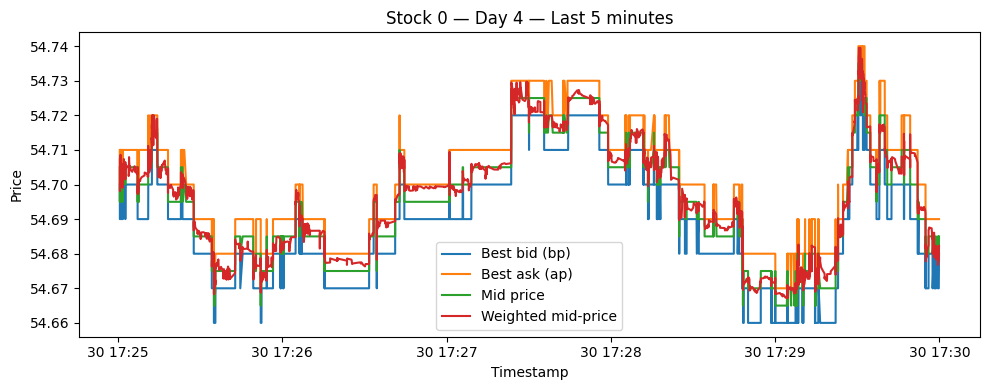

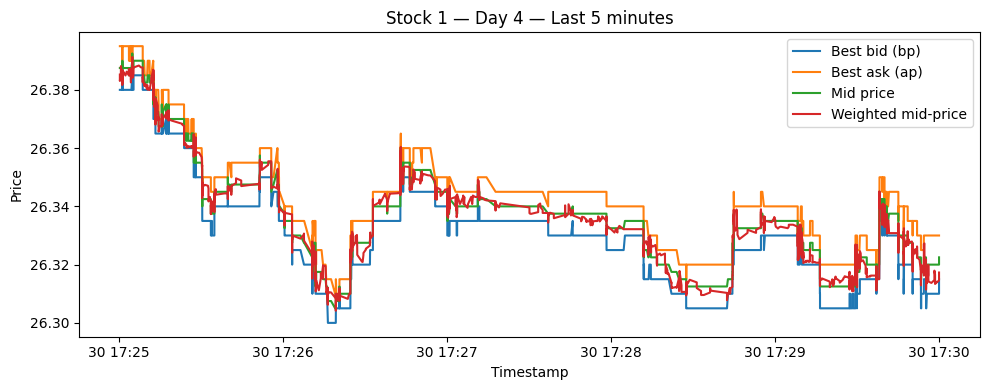

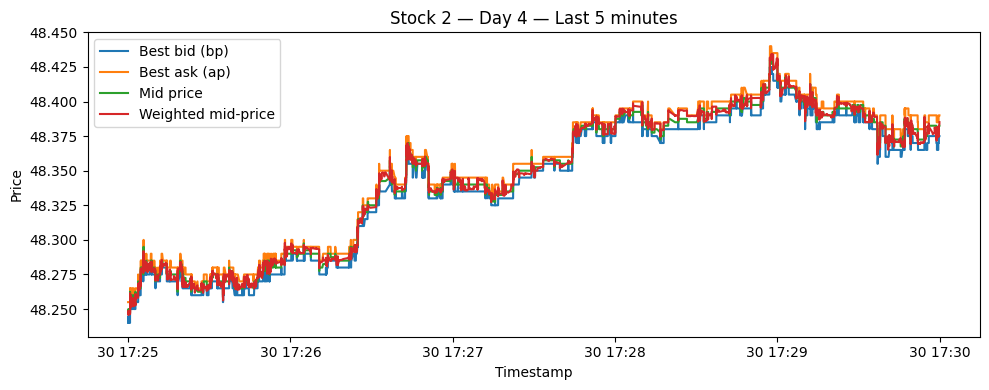

In [23]:
def plot_last_5min_prices(stock_id, day_id=4):
    df = updates[stock_id, day_id].copy()
    df["ts"] = pd.to_datetime(df["ts"])
    df = df.sort_values("ts").reset_index(drop=True)

    t_end = df["ts"].iloc[-1]
    t_start = t_end - pd.Timedelta(minutes=5)
    w = df[df["ts"] >= t_start].copy()

    bp = pd.to_numeric(w["bp"], errors="coerce")
    ap = pd.to_numeric(w["ap"], errors="coerce")
    bq = pd.to_numeric(w["bq"], errors="coerce")
    aq = pd.to_numeric(w["aq"], errors="coerce")

    mid = 0.5 * (bp + ap)
    den = bq + aq
    w_mid = np.where(den > 0, (bp * aq + ap * bq) / den, np.nan)
    w_mid = pd.Series(w_mid, index=w.index)

    plt.figure(figsize=(10, 4))
    plt.plot(w["ts"], bp, label="Best bid (bp)")
    plt.plot(w["ts"], ap, label="Best ask (ap)")
    plt.plot(w["ts"], mid, label="Mid price")
    plt.plot(w["ts"], w_mid, label="Weighted mid-price")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.title(f"Stock {stock_id} — Day {day_id} — Last 5 minutes")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Stock 0.1.2 (you only have 3 stocks in the dataset)
"""for day_id in day_ids:
    for stock_id in [0, 1, 2]:
        plot_last_5min_prices(stock_id, day_ids.index(day_id))"""

for stock_id in [0, 1, 2]:
    plot_last_5min_prices(stock_id, day_id = 4)


On this window:
- bid price and aask price form a clear bid–ask band, with mid price staying in between.
- The weighted mid-price is very close to the mid-price, but slightly shifts toward the side with larger size.


### 2.3 Spread

We compute its distribution in two ways:
- in event time (each quote update has the same weight)
- in calendar time (each second has the same weight, using the last observed spread)

Then we compare both distributions and check whether the spread looks stable during the day.


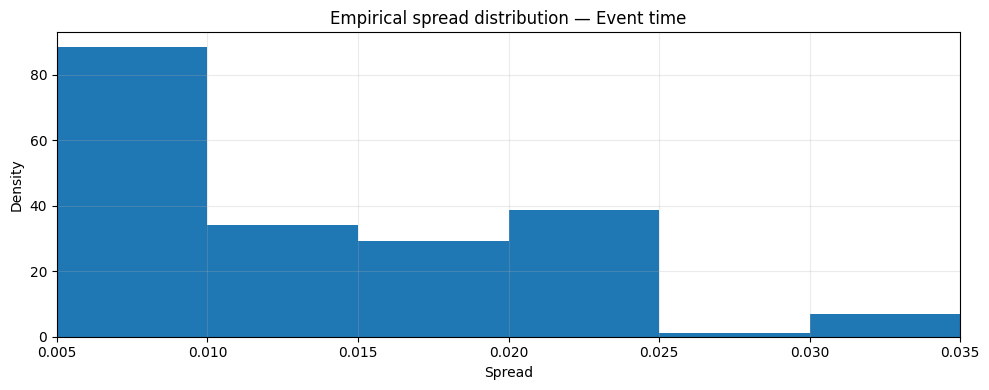

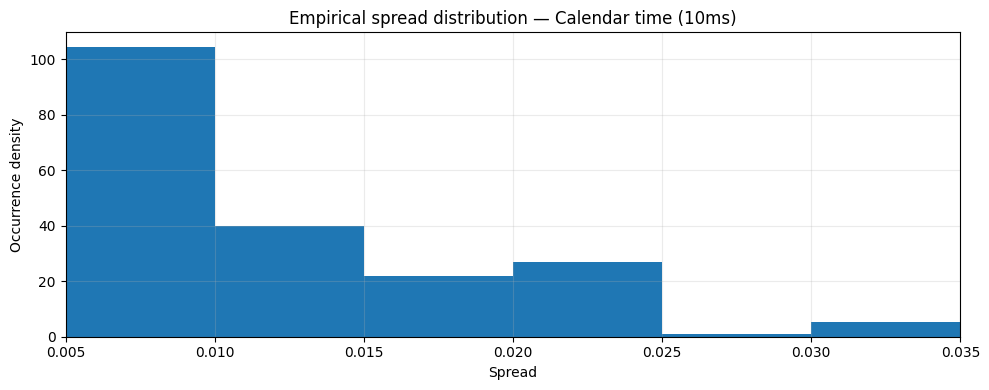

In [24]:
from matplotlib.ticker import MultipleLocator

# --- settings ---
CAL_GRID = "10ms"  
BIN_W = 0.005        
TICK_W = 0.005        
Q_LOW, Q_HIGH = 0.005, 0.995


# --- (stock 0, day 4) ---
df = updates[0, 4].copy()
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values("ts").reset_index(drop=True)

spread = pd.to_numeric(df["ap"], errors="coerce") - pd.to_numeric(df["bp"], errors="coerce")
tmp = pd.DataFrame({"ts": df["ts"], "spread": spread}).dropna()

# --- event time distribution ---
spread_evt = tmp["spread"]

# --- calendar time distribution (handle duplicate timestamps) ---
s = tmp.groupby("ts")["spread"].last().sort_index()
spread_cal = s.resample(CAL_GRID).ffill().dropna()


def plot_spread_hists_same_axis(x_evt, x_cal, title_evt, title_cal):
    x_evt = np.asarray(x_evt, dtype=float)
    x_cal = np.asarray(x_cal, dtype=float)

    x_all = np.concatenate([x_evt, x_cal])
    ql, qh = np.quantile(x_all, [Q_LOW, Q_HIGH])
    xmin = np.floor(ql / BIN_W) * BIN_W
    xmax = np.ceil(qh / BIN_W) * BIN_W
    bins = np.arange(xmin, xmax + BIN_W, BIN_W)

    # Event time
    plt.figure(figsize=(10, 4))
    plt.hist(x_evt, bins=bins, density=True)
    plt.xlim(xmin, xmax)
    plt.gca().xaxis.set_major_locator(MultipleLocator(TICK_W))
    plt.xlabel("Spread")
    plt.ylabel("Density")
    plt.title(title_evt)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Calendar time
    plt.figure(figsize=(10, 4))
    plt.hist(x_cal, bins=bins, density=True)
    plt.xlim(xmin, xmax)
    plt.gca().xaxis.set_major_locator(MultipleLocator(TICK_W))
    plt.xlabel("Spread")
    plt.ylabel("Occurrence density")
    plt.title(title_cal)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_spread_hists_same_axis(
    spread_evt,
    spread_cal,
    "Empirical spread distribution — Event time",
    f"Empirical spread distribution — Calendar time ({CAL_GRID})"
)

- On this sample, the event-time and calendar-time spread distributions are very similar.  

- This suggests that the spread level does not change much between low-activity and high-activity periods: weighting each update equally (event time) or weighting each time instant equally (calendar time) leads to almost the same empirical distribution.  

- Here, most observed spreads concentrate around 1 to 4 ticks, i.e. roughly 0.005 to 0.020, which indicates a fairly stable “typical” transaction cost over the day.


### 2.4 Imbalance and mid-price moves

We study whether top-of-book imbalance predicts the direction of the next non-zero mid-price move.

For each quote update we compute:
- Mid-price: $m_t = \frac{bp_t + ap_t}{2}$
- Spread: $s_t = ap_t - bp_t$
- Imbalance: $I_t = \frac{bq_t - aq_t}{bq_t + aq_t}$ (when $bq_t + aq_t > 0$)

Target variable (direction of the next non-zero move):
- Let $m_{t^+}$ be the next mid-price different from $m_t$
- $y_t = \mathrm{sign}(m_{t^+} - m_t) \in \{-1, +1\}$

We then estimate predictability by binning:
- $\mathbb{P}(y_t = +1 \mid I_t \in \text{bin})$ (imbalance)
- $\mathbb{P}(y_t = +1 \mid s_t \in \text{bin})$ (spread)
- optionally, repeat $\mathbb{P}(y_t = +1 \mid I_t \in \text{bin})$ within spread buckets (in ticks)

To measure predictability we estimate, for each bin, the empirical probability that the next (non-zero) mid-price move is upward.

We define the label $y_t \in \{-1,+1\}$:
- $y_t = +1$ if $m_{t^+} > m_t$
- $y_t = -1$ if $m_{t^+} < m_t$

Inside each bin (imbalance or spread), we compute the sample mean $\bar y = \mathbb{E}[y \mid \text{bin}]$.
Since $y$ only takes values $\pm 1$:
- $\mathbb{E}[y] = P(\text{up}) - P(\text{down})$
- and $P(\text{up}) + P(\text{down}) = 1$

Therefore:
$$P(\text{up} \mid \text{bin}) = \frac{1 + \mathbb{E}[y \mid \text{bin}]}{2} = \frac{1 + \bar y}{2}.$$


C:\Users\Arnaud\AppData\Local\Temp\ipykernel_3132\2266722576.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab_imb = data.groupby("imb_bin")["y"].agg(["count", "mean"]).reset_index()


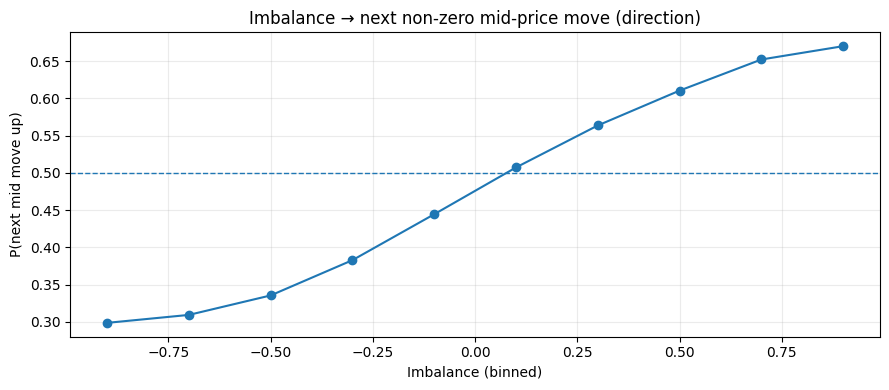

,bin_center,count,p_up
0,-0.9005,6160,0.298539
1,-0.7000,11699,0.309257
2,-0.5000,19376,0.335415
3,-0.3000,24543,0.382798
4,-0.1000,29665,0.444497
5,0.1000,29206,0.507362
6,0.3000,26745,0.563769
7,0.5000,22288,0.610598
8,0.7000,17620,0.652384
9,0.9000,14209,0.670279


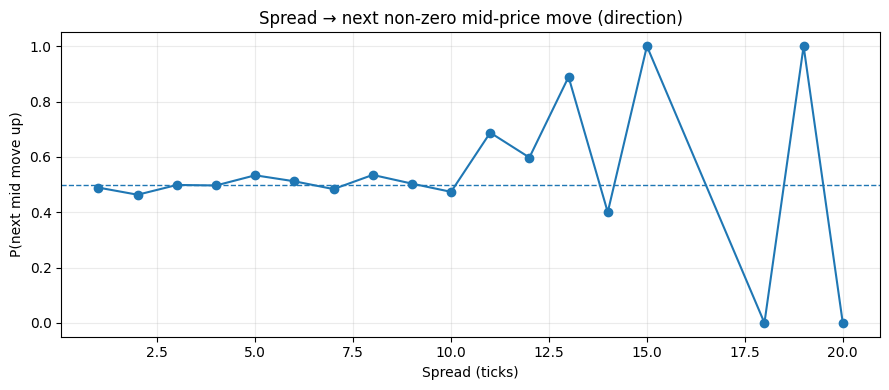

,spread_ticks,count,p_up
0,1,10660,0.488837
1,2,49654,0.463105
2,3,79392,0.498463
3,4,40587,0.496612
4,5,12541,0.533371
5,6,3942,0.511669
6,7,2124,0.483522
7,8,1165,0.534764
8,9,753,0.503320
9,10,378,0.473545


In [25]:
# ---one sample (stock 0, day 4) ---
df = updates[1, 4].copy()
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values("ts").reset_index(drop=True)

bp = pd.to_numeric(df["bp"], errors="coerce")
ap = pd.to_numeric(df["ap"], errors="coerce")
bq = pd.to_numeric(df["bq"], errors="coerce")
aq = pd.to_numeric(df["aq"], errors="coerce")

mid = 0.5 * (bp + ap)
spread = ap - bp
den = bq + aq
imb = (bq - aq) / den
imb = imb.where(den > 0)

# --- next non-zero mid move direction y in {-1,+1} ---
g = mid.ne(mid.shift()).cumsum()
group_mid = mid.groupby(g).first()
next_mid = g.map(group_mid.shift(-1))
y = np.sign(next_mid - mid).replace(0, np.nan)

data = pd.DataFrame({"imb": imb, "spread": spread, "y": y}).dropna()
data["y"] = data["y"].astype(int)

# --- Visualization: P(up) vs imbalance bins ---
bins_imb = np.linspace(-1, 1, 11)
data["imb_bin"] = pd.cut(data["imb"], bins=bins_imb, include_lowest=True)
tab_imb = data.groupby("imb_bin")["y"].agg(["count", "mean"]).reset_index()
tab_imb["p_up"] = (1 + tab_imb["mean"]) / 2
tab_imb["bin_center"] = tab_imb["imb_bin"].apply(lambda b: 0.5 * (b.left + b.right))

plt.figure(figsize=(9, 4))
plt.plot(tab_imb["bin_center"], tab_imb["p_up"], marker="o")
plt.axhline(0.5, linewidth=1, linestyle="--")
plt.xlabel("Imbalance (binned)")
plt.ylabel("P(next mid move up)")
plt.title("Imbalance → next non-zero mid-price move (direction)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

display(tab_imb[["bin_center", "count", "p_up"]])

# --- Visualization: P(up) vs spread ---
tick = 0.005
data["spread_ticks"] = (data["spread"] / tick).round().astype(int)

tab_sp = data.groupby("spread_ticks")["y"].agg(["count", "mean"]).reset_index()
tab_sp["p_up"] = (1 + tab_sp["mean"]) / 2

plt.figure(figsize=(9, 4))
plt.plot(tab_sp["spread_ticks"], tab_sp["p_up"], marker="o")
plt.axhline(0.5, linewidth=1, linestyle="--")
plt.xlabel("Spread (ticks)")
plt.ylabel("P(next mid move up)")
plt.title("Spread → next non-zero mid-price move (direction)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

display(tab_sp[["spread_ticks", "count", "p_up"]])



It seems that imbalance is a pretty good predictor of the next move given the graph plotted above. Moreover we have good distribution in termes of level of imbalances (the count within each bins is of the same magnitude)

To the contrary, the tick does not seem to be a good predictor, the plot does not show any link/correlation between spread and next price move. Moreover the distribution of events with regards to the spread is highly uneven (low counts for high spreads)

A trader could have the idea to do a logistic regression to do make some profit. We can do so and see the predictive power of these features (imbalance / spread).


,model,AUC_test
0,imbalance,0.695472
1,spread,0.515045
2,imbalance + spread,0.695473


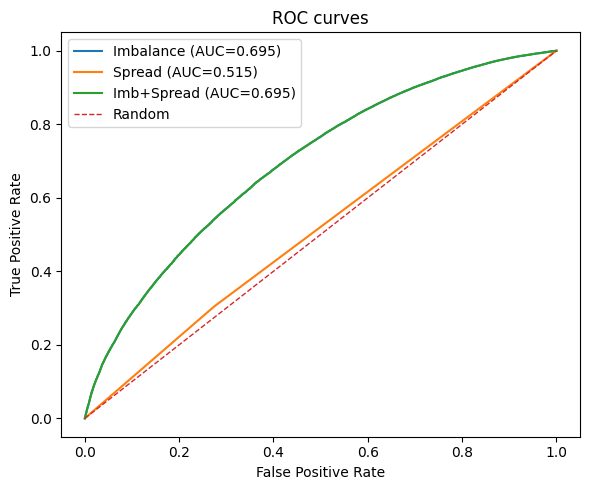

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# --- data: stock 0, day 4 ---
df = updates[0, 4].copy()
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values("ts").reset_index(drop=True)

bp = pd.to_numeric(df["bp"], errors="coerce")
ap = pd.to_numeric(df["ap"], errors="coerce")
bq = pd.to_numeric(df["bq"], errors="coerce")
aq = pd.to_numeric(df["aq"], errors="coerce")

mid = 0.5 * (bp + ap)
spread = ap - bp
den = bq + aq
imb = ((bq - aq) / den).where(den > 0)

# next non-zero mid move direction
g = mid.ne(mid.shift()).cumsum()
mid_by_block = mid.groupby(g).first()
next_mid = g.map(mid_by_block.shift(-1))
y = np.sign(next_mid - mid).replace(0, np.nan)

data = pd.DataFrame({"imb": imb, "spread": spread, "y": y}).dropna().reset_index(drop=True)
data["y01"] = (data["y"] > 0).astype(int)

# --- time split ---
cut = int(0.7 * len(data))
train = data.iloc[:cut]
test = data.iloc[cut:]

ytr = train["y01"].values
yte = test["y01"].values

Xtr_imb = train[["imb"]].values
Xte_imb = test[["imb"]].values
Xtr_sp = train[["spread"]].values
Xte_sp = test[["spread"]].values
Xtr_both = train[["imb", "spread"]].values
Xte_both = test[["imb", "spread"]].values

# --- fit models ---
m_imb = LogisticRegression(max_iter=2000).fit(Xtr_imb, ytr)
m_sp = LogisticRegression(max_iter=2000).fit(Xtr_sp, ytr)
m_both = LogisticRegression(max_iter=2000).fit(Xtr_both, ytr)

p_imb = m_imb.predict_proba(Xte_imb)[:, 1]
p_sp = m_sp.predict_proba(Xte_sp)[:, 1]
p_both = m_both.predict_proba(Xte_both)[:, 1]

auc_imb = roc_auc_score(yte, p_imb)
auc_sp = roc_auc_score(yte, p_sp)
auc_both = roc_auc_score(yte, p_both)

auc_df = pd.DataFrame({
    "model": ["imbalance", "spread", "imbalance + spread"],
    "AUC_test": [auc_imb, auc_sp, auc_both]
})
display(auc_df)

# --- ROC curves ---
fpr_imb, tpr_imb, _ = roc_curve(yte, p_imb)
fpr_sp, tpr_sp, _ = roc_curve(yte, p_sp)
fpr_both, tpr_both, _ = roc_curve(yte, p_both)

plt.figure(figsize=(6, 5))
plt.plot(fpr_imb, tpr_imb, label=f"Imbalance (AUC={auc_imb:.3f})")
plt.plot(fpr_sp, tpr_sp, label=f"Spread (AUC={auc_sp:.3f})")
plt.plot(fpr_both, tpr_both, label=f"Imb+Spread (AUC={auc_both:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.tight_layout()
plt.show()

The ROC curves show that imbalance has strong predictive power for the next non-zero mid-price move on this sample: AUC ≈ 0.695, clearly above the random baseline (0.5).  
In contrast, spread alone is almost uninformative for direction: AUC ≈ 0.515, close to random.  
Adding spread to imbalance does not improve performance here (Imb+Spread has the same AUC), suggesting that most of the directional information is already captured by imbalance.


___

## III : Trades and quotes

### 3.1 Dataset


To compare the trades files with the updates files for each stock for each day, we will reconstruct each trade files using only the data contained within the updates files. If they match, we have the expected result. Otherwise, we may have inconsistencies. Since we have some type T data inside the updates files, we assume they are the trades we are looking to match. 

In [27]:
df_updates = updates[0,0]

In [28]:
df_trades = trades[0,0]
df_trades.head()

,price,qty,ts
0,55.00,2,2026-01-26 09:00:27.018202
1,55.00,10,2026-01-26 09:00:27.018202
2,55.00,10,2026-01-26 09:00:27.018202
3,54.97,446,2026-01-26 09:00:27.041728
4,54.97,24,2026-01-26 09:00:27.042153


In [29]:
def reconstruct_trades_from_updates(df_updates):
    trades_mask = df_updates['type'] == 'T'
    df_trades_reconstructed = df_updates[trades_mask].copy()
    df_trades_reconstructed['price'] = df_trades_reconstructed['bp'].fillna(df_trades_reconstructed['ap']) # Try to determine price: use bp if not NaN, else use ap
    df_trades_reconstructed['qty'] = df_trades_reconstructed['bq'].fillna(df_trades_reconstructed['aq']) # Try to determine quantity: use bq if not NaN, else use aq
    df_trades_reconstructed = df_trades_reconstructed.dropna(subset=['price', 'qty']) # We filter the ne that remain NaN
    df_trades_reconstructed = df_trades_reconstructed[['price', 'qty', 'ts']].reset_index(drop=True)
    df_trades_reconstructed['qty'] = df_trades_reconstructed['qty'].astype(int)
    return df_trades_reconstructed

df_trades_original = trades[0, 0]
df_trades_reconstructed = reconstruct_trades_from_updates(updates[0, 0])

print("Original trades file:")
print(f"Shape: {df_trades_original.shape}")
print(df_trades_original.head())

print("Reconstructed trades file:")
print(f"Shape: {df_trades_reconstructed.shape}")
print(df_trades_reconstructed.head())

Original trades file:
Shape: (19076, 3)
   price  qty                         ts
0  55.00    2 2026-01-26 09:00:27.018202
1  55.00   10 2026-01-26 09:00:27.018202
2  55.00   10 2026-01-26 09:00:27.018202
3  54.97  446 2026-01-26 09:00:27.041728
4  54.97   24 2026-01-26 09:00:27.042153
Reconstructed trades file:
Shape: (9589, 3)
   price  qty                         ts
0  54.97  446 2026-01-26 09:00:27.018202
1  54.97  446 2026-01-26 09:00:27.018202
2  54.97  446 2026-01-26 09:00:27.018202
3  54.97  446 2026-01-26 09:00:27.041727
4  54.91  212 2026-01-26 09:00:27.042152


Even if the data from the begining is the same, the differences in shapes suggest that using updates type="T" isn't enough to match all the data from trades dataset. Using the algorithm proposed in the course would be a solution, however we had issues programming it.

End of report
___
